# Globals

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from PIL import Image
from numba import jit, f8

from IPython.display import clear_output

In [ ]:
def debug(is_a_debugged_call, message, clear_before_printing = False):
  if is_a_debugged_call:
    if clear_before_printing:
      clear_output(wait=True)
    print(message)

# 1. Laplace equation

## a

### Commons

In [ ]:
V_top = 1e3
V_right = 0
V_bottom = 0
V_left = 0
e_max = 1e-3

In [ ]:
def construct(
    n,
    is_a_debugged_call = False,
    clear_before_printing = False
  ):
  A = -4 * np.eye((n*n))
  b = np.zeros((n*n))

  for i in range(1,n+1):
    for j in range(1,n+1):
      r = (i-1)*n + j

      if j < (n):
        A[r-1][r+1 -1] = 1
      else:
        b[r-1] -= V_top

      if i < (n):
        A[r-1][r+n -1] = 1
      else:
        b[r-1] -= V_right

      if (j-1) > 0:
        A[r-1][r-1 -1] = 1
      else:
        b[r-1] -= V_bottom

      if (i-1) > 0:
        A[r-1][r-n -1] = 1
      else:
        b[r-1] -= V_left

  return A, b

In [ ]:
def get_diagonal_elements_matrix(matrix):
  diagonal_elements = matrix.diagonal()
  size = matrix.shape
  diagonal_matrix = np.zeros(size)
  np.fill_diagonal(diagonal_matrix, diagonal_elements)

  return diagonal_matrix

In [ ]:
def construct_error_matrices(
    n,
    is_a_debugged_call = False,
    clear_before_printing = False
):
  A_e = np.zeros((n*n, n*n))
  b_e = np.zeros((n*n))

  for i in range(1,n+1):
    for j in range(1,n+1):
      r = (i-1)*n + j

      if j < (n):
        A_e[r-1][r+1 -1] = 1/4
      else:
        b_e[r-1] -= V_top/4

      if i < (n):
        A_e[r-1][r+n -1] = 1/4
      else:
        b_e[r-1] -= V_right/4

      if (j-1) > 0:
        A_e[r-1][r-1 -1] = 1/4
      else:
        b_e[r-1] -= V_bottom/4

      if (i-1) > 0:
        A_e[r-1][r-n -1] = 1/4
      else:
        b_e[r-1] -= V_left/4

  return A_e, b_e

In [ ]:
def solve_using_a_relaxation_method(
    n,
    alpha,
    beta,
    e_max,
    is_a_debugged_call = False,
    clear_before_printing = False,
    iterations_limit = 0
):
  e = e_max * np.ones((n*n))
  V = np.zeros((n*n))

  i = 0
  iterations = []

  average_e = []
  max_e = []
  max_e_element = e_max

  A_e, b_e = construct_error_matrices(
      n,
      is_a_debugged_call,
      clear_before_printing
  )

  while max_e_element >= e_max:
    i += 1
    iterations.append(i)

    V_next = beta + np.dot(alpha,V)

    e = abs(V_next - np.dot(A_e, V_next) + b_e)
    debug(is_a_debugged_call, f'Iteration #{i}', clear_before_printing)
    debug(is_a_debugged_call, f'V_{i} = ')
    debug(is_a_debugged_call, V_next)
    debug(is_a_debugged_call, f'e_{i} = ')
    debug(is_a_debugged_call, e)

    average_e.append(np.sum(e)/len(e))
    max_e_element = np.max(e)
    max_e.append(max_e_element)
    debug(
        is_a_debugged_call,
        f'Max error for iteration #{i} = {max_e_element}',
        # clear_before_printing
    )

    V = V_next

    if iterations_limit > 0 and i == iterations_limit:
      break

  return V, iterations, average_e, max_e

In [ ]:
def unpack_V(V):
  n = int(np.sqrt(len(V)))
  unpacked_V = np.zeros((n,n))
  r = -1
  for i in range(len(V)):
    c = i%n
    if c == 0:
      r += 1
    unpacked_V[r][c] = V[i]

  return unpacked_V

### Jacobi

In [ ]:
def solve_using_Jacobi(
    n,
    e_max,
    is_a_debugged_call = False,
    clear_before_printing = False
):
  A, b = construct(n, is_a_debugged_call, clear_before_printing)

  D = get_diagonal_elements_matrix(A)
  D_inverse = np.linalg.inv(D)

  alpha = np.dot(D_inverse, (D-A))
  beta = np.dot(D_inverse, b)

  return solve_using_a_relaxation_method(
    n,
    alpha,
    beta,
    e_max,
    is_a_debugged_call,
    clear_before_printing
  )

In [ ]:
V_Jacobi, iterations_Jacobi, average_e_Jacobi, max_e_Jacobi = solve_using_Jacobi(
    99,
    1e-3,
    True,
    True
)

Iteration #10735
V_10735 = 
[1.07437940e-01 2.14990720e-01 3.22773336e-01 ... 2.09055066e+02
 3.02124472e+02 4.99888564e+02]
e_10735
[9.84695571e-07 1.96939526e-06 2.95021700e-06 ... 2.95851220e-06
 1.97494637e-06 9.87475232e-07]
Max error for iteration #10735 = 0.0009994864306577256


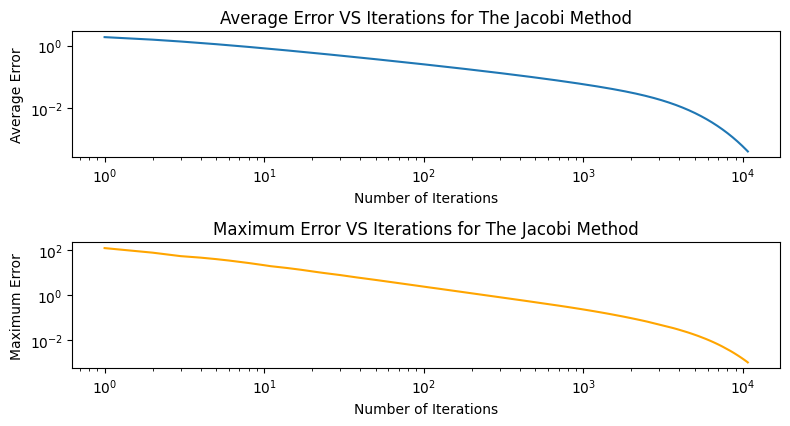

In [ ]:
plt.figure(figsize=(8, 6))

# First subplot
plt.subplot(3, 1, 1)  # 3 rows, 1 column, first subplot
plt.loglog(iterations_Jacobi, average_e_Jacobi)
plt.title(f'Average Error VS Iterations for The Jacobi Method')
plt.ylabel('Average Error')
plt.xlabel('Number of Iterations')

# Second subplot
plt.subplot(3, 1, 2)  # 3 rows, 1 column, second subplot
plt.loglog(iterations_Jacobi, max_e_Jacobi, color='orange')
plt.title(f'Maximum Error VS Iterations for The Jacobi Method')
plt.ylabel('Maximum Error')
plt.xlabel('Number of Iterations')

plt.tight_layout()

### Gauss-Seidel

In [ ]:
def solve_using_GS(
    n,
    e_max,
    is_a_debugged_call = False,
    clear_before_printing = False,
    iterations_limit = 0,
):
  A, b = construct(n)

  D_L = np.tril(A)
  D_L_inverse = np.linalg.inv(D_L)

  alpha = np.dot(D_L_inverse, (D_L - A))
  beta = np.dot(D_L_inverse, b)

  return solve_using_a_relaxation_method(
    n,
    alpha,
    beta,
    e_max,
    is_a_debugged_call,
    clear_before_printing,
    iterations_limit
  )

In [ ]:
V_GS, iterations_GS, average_e_GS, max_e_GS = solve_using_GS(
    99,
    1e-3,
    True,
    True
)

Iteration #5393
V_5393 = 
[1.07340473e-01 2.14797948e-01 3.22487508e-01 ... 2.09055348e+02
 3.02124662e+02 4.99888660e+02]
e_5393 = 
[2.06531551e-06 3.61024067e-06 5.15009920e-06 ... 9.41061074e-07
 4.70530949e-07 0.00000000e+00]
Max error for iteration #5393 = 0.0009997240043730926


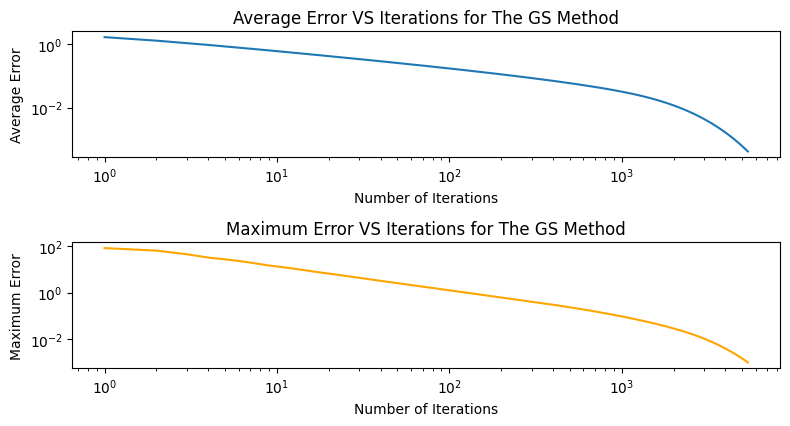

In [ ]:
plt.figure(figsize=(8, 6))

# First subplot
plt.subplot(3, 1, 1)  # 3 rows, 1 column, first subplot
plt.loglog(iterations_GS, average_e_GS, label='Average Error')
plt.title(f'Average Error VS Iterations for The GS Method')
plt.ylabel('Average Error')
plt.xlabel('Number of Iterations')

# Second subplot
plt.subplot(3, 1, 2)  # 3 rows, 1 column, second subplot
plt.loglog(iterations_GS, max_e_GS, label='Maximum Error', color='orange')
plt.title(f'Maximum Error VS Iterations for The GS Method')
plt.ylabel('Maximum Error')
plt.xlabel('Number of Iterations')

plt.tight_layout()

### SOR

In [ ]:
def solve_using_SOR(
    n,
    e_max,
    w,
    is_a_debugged_call = False,
    clear_before_printing = False,
    iterations_limit = 0
):
  A, b = construct(n)

  D_L = np.tril(A)
  D = get_diagonal_elements_matrix(A)
  L = D_L - D
  D_wL = D + w*L
  D_wL_inverse = np.linalg.inv(D_wL)

  alpha = -np.dot(D_wL_inverse, (w*(A-L) - D))
  # R = A - D_L
  # alpha = np.dot(D_L_inverse, ((1-w)*D_L - R))
  beta = w * np.dot(D_wL_inverse, b)

  return solve_using_a_relaxation_method(
    n,
    alpha,
    beta,
    e_max,
    is_a_debugged_call,
    clear_before_printing,
    iterations_limit
  )

#### w = 0.5

In [ ]:
w05 = 0.5
V_SOR_w05, iterations_SOR_w05, average_e_SOR_w05, max_e_SOR_w05 = solve_using_SOR(
    99,
    1e-3,
    w05,
    True,
    True
)

Iteration #16130
V_16130 = 
[1.07405091e-01 2.14925722e-01 3.22676918e-01 ... 2.09055159e+02
 3.02124534e+02 4.99888596e+02]
e_16130 = 
[1.33462328e-06 2.50066945e-06 3.66387612e-06 ... 2.26665460e-06
 1.45801494e-06 6.48197130e-07]
Max error for iteration #16130 = 0.0009998779032400762


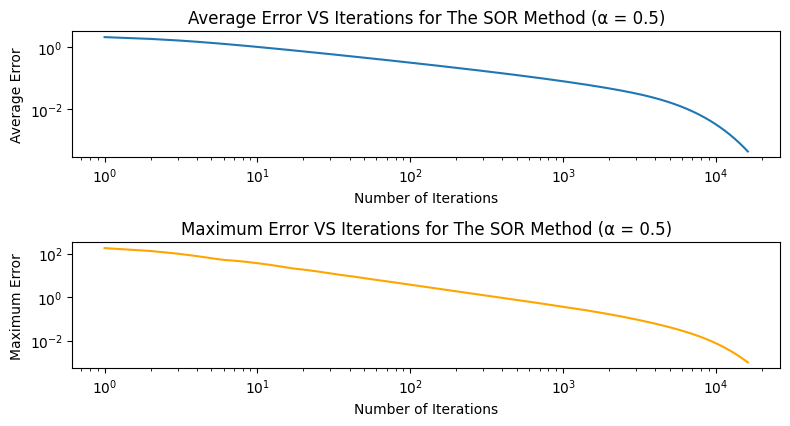

In [ ]:
plt.figure(figsize=(8, 6))

# First subplot
plt.subplot(3, 1, 1)  # 3 rows, 1 column, first subplot
plt.loglog(iterations_SOR_w05, average_e_SOR_w05)
plt.title(f'Average Error VS Iterations for The SOR Method (α = {w05})')
plt.ylabel('Average Error')
plt.xlabel('Number of Iterations')

# Second subplot
plt.subplot(3, 1, 2)  # 3 rows, 1 column, second subplot
plt.loglog(iterations_SOR_w05, max_e_SOR_w05, color='orange')
plt.title(f'Maximum Error VS Iterations for The SOR Method (α = {w05})')
plt.ylabel('Maximum Error')
plt.xlabel('Number of Iterations')

plt.tight_layout()

#### w = 1

In [ ]:
w1 = 1
V_SOR_w1, iterations_SOR_w1, average_e_SOR_w1, max_e_SOR_w1 = solve_using_SOR(
    99,
    1e-3,
    w1,
    True,
    True
)

Iteration #5393
V_5393 = 
[1.07340473e-01 2.14797948e-01 3.22487508e-01 ... 2.09055348e+02
 3.02124662e+02 4.99888660e+02]
e_5393 = 
[2.06531551e-06 3.61024067e-06 5.15009920e-06 ... 9.41061074e-07
 4.70530949e-07 0.00000000e+00]
Max error for iteration #5393 = 0.0009997240043730926


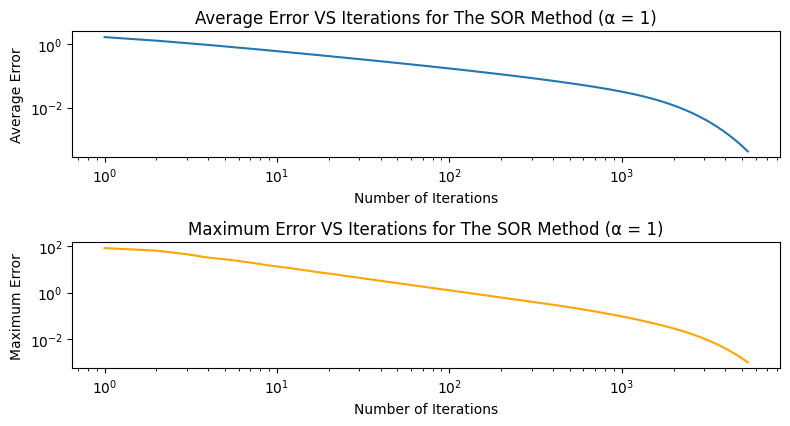

In [ ]:
plt.figure(figsize=(8, 6))

# First subplot
plt.subplot(3, 1, 1)  # 3 rows, 1 column, first subplot
plt.loglog(iterations_SOR_w1, average_e_SOR_w1)
plt.title(f'Average Error VS Iterations for The SOR Method (α = {w1})')
plt.ylabel('Average Error')
plt.xlabel('Number of Iterations')

# Second subplot
plt.subplot(3, 1, 2)  # 3 rows, 1 column, second subplot
plt.loglog(iterations_SOR_w1, max_e_SOR_w1, color='orange')
plt.title(f'Maximum Error VS Iterations for The SOR Method (α = {w1})')
plt.ylabel('Maximum Error')
plt.xlabel('Number of Iterations')

plt.tight_layout()

#### w = 1.25

In [ ]:
w125 = 1.25
V_SOR_w125, iterations_SOR_w125, average_e_SOR_w125, max_e_SOR_w125 = solve_using_SOR(
    99,
    1e-3,
    w125,
    True,
    True
)

Iteration #3246
V_3246 = 
[1.07277079e-01 2.14672703e-01 3.22302012e-01 ... 2.09055539e+02
 3.02124790e+02 4.99888725e+02]
e_3246 = 
[2.83725931e-06 4.78043382e-06 6.71572540e-06 ... 3.03292296e-07
 4.55191525e-07 6.06389847e-07]
Max error for iteration #3246 = 0.0009984586585858324


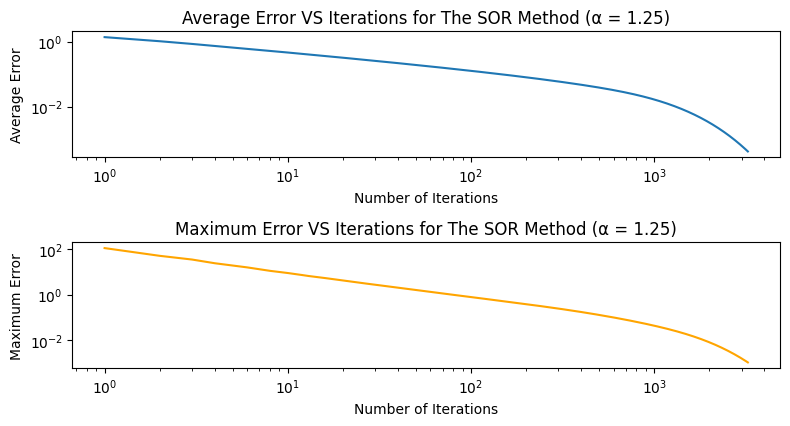

In [ ]:
plt.figure(figsize=(8, 6))

# First subplot
plt.subplot(3, 1, 1)  # 3 rows, 1 column, first subplot
plt.loglog(iterations_SOR_w125, average_e_SOR_w125)
plt.title(f'Average Error VS Iterations for The SOR Method (α = {w125})')
plt.ylabel('Average Error')
plt.xlabel('Number of Iterations')

# Second subplot
plt.subplot(3, 1, 2)  # 3 rows, 1 column, second subplot
plt.loglog(iterations_SOR_w125, max_e_SOR_w125, color='orange')
plt.title(f'Maximum Error VS Iterations for The SOR Method (α = {w125})')
plt.ylabel('Maximum Error')
plt.xlabel('Number of Iterations')

plt.tight_layout()

#### w = 1.5

In [ ]:
w15 = 1.5
V_SOR_w15, iterations_SOR_w15, average_e_SOR_w15, max_e_SOR_w15 = solve_using_SOR(
    99,
    1e-3,
    w15,
    True,
    True
)

Iteration #1814
V_1814 = 
[1.07145715e-01 2.14413337e-01 3.21918117e-01 ... 2.09055908e+02
 3.02125038e+02 4.99888850e+02]
e_1814 = 
[4.51848933e-06 7.32475261e-06 1.01155250e-05 ... 2.55452247e-06
 2.12722227e-06 1.69908239e-06]
Max error for iteration #1814 = 0.0009975651394427132


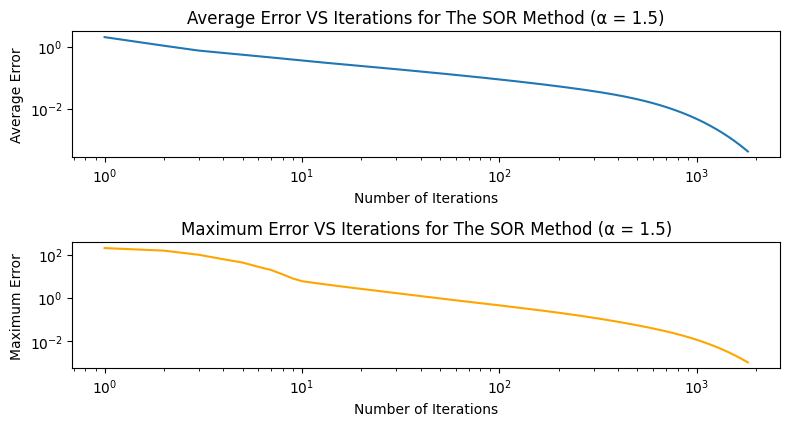

In [ ]:
plt.figure(figsize=(8, 6))

# First subplot
plt.subplot(3, 1, 1)  # 3 rows, 1 column, first subplot
plt.loglog(iterations_SOR_w15, average_e_SOR_w15, label='Average Error')
plt.title(f'Average Error VS Iterations for The SOR Method (α = {w15})')
plt.ylabel('Average Error')
plt.xlabel('Number of Iterations')

# Second subplot
plt.subplot(3, 1, 2)  # 3 rows, 1 column, second subplot
plt.loglog(iterations_SOR_w15, max_e_SOR_w15, label='Maximum Error', color='orange')
plt.title(f'Maximum Error VS Iterations for The SOR Method (α = {w15})')
plt.ylabel('Maximum Error')
plt.xlabel('Number of Iterations')

plt.tight_layout()

#### w = 1.75

In [ ]:
w175 = 1.75
V_SOR_w175, iterations_SOR_w175, average_e_SOR_w175, max_e_SOR_w175 = solve_using_SOR(
    99,
    1e-3,
    w175,
    True,
    True
)

Iteration #790
V_790 = 
[1.06732251e-01 2.13598879e-01 3.20715427e-01 ... 2.09056944e+02
 3.02125734e+02 4.99889201e+02]
e_790 = 
[1.07534231e-05 1.67168605e-05 2.26223066e-05 ... 7.57882069e-06
 5.83799880e-06 4.10349890e-06]
Max error for iteration #790 = 0.0009964831587296885


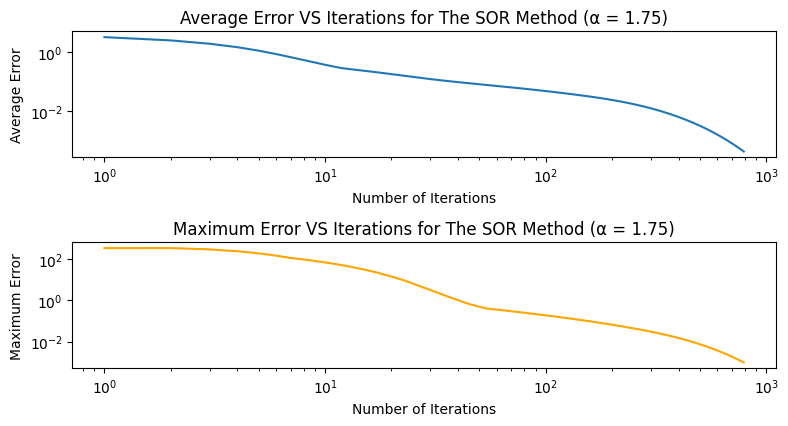

In [ ]:
plt.figure(figsize=(8, 6))

# First subplot
plt.subplot(3, 1, 1)  # 3 rows, 1 column, first subplot
plt.loglog(iterations_SOR_w175, average_e_SOR_w175, label='Average Error')
plt.title(f'Average Error VS Iterations for The SOR Method (α = {w175})')
plt.ylabel('Average Error')
plt.xlabel('Number of Iterations')

# Second subplot
plt.subplot(3, 1, 2)  # 3 rows, 1 column, second subplot
plt.loglog(iterations_SOR_w175, max_e_SOR_w175, label='Maximum Error', color='orange')
plt.title(f'Maximum Error VS Iterations for The SOR Method (α = {w175})')
plt.ylabel('Maximum Error')
plt.xlabel('Number of Iterations')

plt.tight_layout()

#### w = 1.99

In [ ]:
w199 = 1.99
V_SOR_w199, iterations_SOR_w199, average_e_SOR_w199, max_e_SOR_w199 = solve_using_SOR(
    99,
    1e-3,
    w199,
    True,
    True
)

Iteration #1389
V_1389 = 
[1.09439818e-01 2.18992383e-01 3.28742389e-01 ... 2.09061063e+02
 3.02128468e+02 4.99890568e+02]
e_1389 = 
[2.22489874e-06 9.27550014e-06 1.91301864e-05 ... 3.24242805e-06
 5.74309939e-06 2.62724222e-06]
Max error for iteration #1389 = 0.0009914990950510294


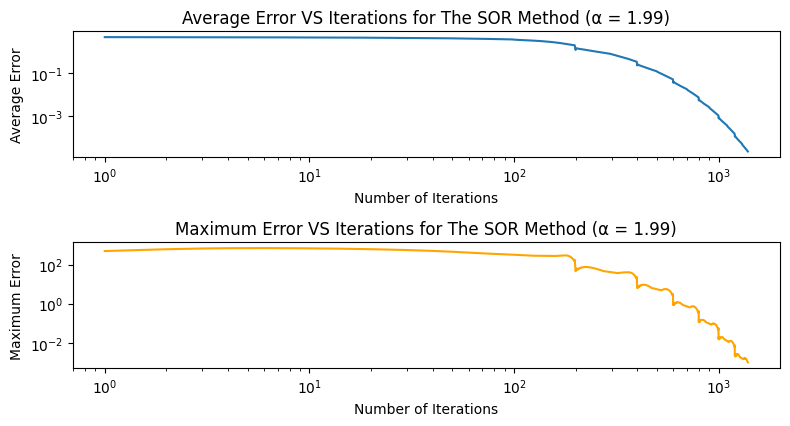

In [ ]:
plt.figure(figsize=(8, 6))

# First subplot
plt.subplot(3, 1, 1)  # 3 rows, 1 column, first subplot
plt.loglog(iterations_SOR_w199, average_e_SOR_w199, label='Average Error')
plt.title(f'Average Error VS Iterations for The SOR Method (α = {w199})')
plt.ylabel('Average Error')
plt.xlabel('Number of Iterations')

# Second subplot
plt.subplot(3, 1, 2)  # 3 rows, 1 column, second subplot
plt.loglog(iterations_SOR_w199, max_e_SOR_w199, label='Maximum Error', color='orange')
plt.title(f'Maximum Error VS Iterations for The SOR Method (α = {w199})')
plt.ylabel('Maximum Error')
plt.xlabel('Number of Iterations')

plt.tight_layout()

#### Combined graphs

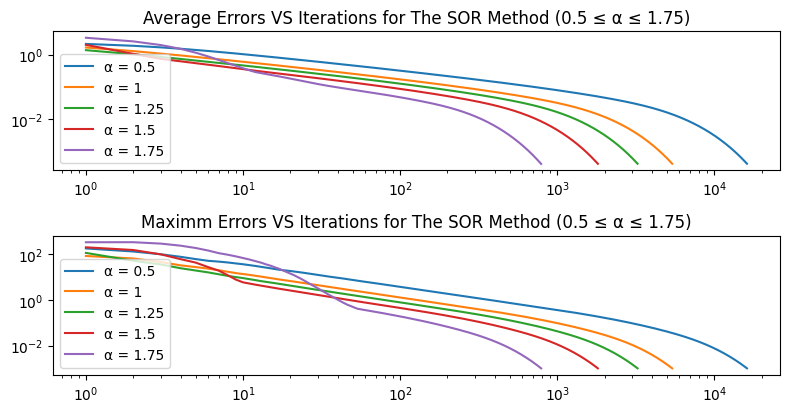

In [ ]:
plt.figure(figsize=(8, 6))

# First subplot
plt.subplot(3, 1, 1)  # 3 rows, 1 column, first subplot
plt.loglog(iterations_SOR_w05, average_e_SOR_w05, label=f'α = {w05}')
plt.loglog(iterations_SOR_w1, average_e_SOR_w1, label=f'α = {w1}')
plt.loglog(iterations_SOR_w125, average_e_SOR_w125, label=f'α = {w125}')
plt.loglog(iterations_SOR_w15, average_e_SOR_w15, label=f'α = {w15}')
plt.loglog(iterations_SOR_w175, average_e_SOR_w175, label=f'α = {w175}')
plt.title(f'Average Errors VS Iterations for The SOR Method ({w05} ≤ α ≤ {w175})')
plt.legend()

# Second subplot
plt.subplot(3, 1, 2)  # 3 rows, 1 column, second subplot
plt.loglog(iterations_SOR_w05, max_e_SOR_w05, label=f'α = {w05}')
plt.loglog(iterations_SOR_w1, max_e_SOR_w1, label=f'α = {w1}')
plt.loglog(iterations_SOR_w125, max_e_SOR_w125, label=f'α = {w125}')
plt.loglog(iterations_SOR_w15, max_e_SOR_w15, label=f'α = {w15}')
plt.loglog(iterations_SOR_w175, max_e_SOR_w175, label=f'α = {w175}')
plt.title(f'Maximm Errors VS Iterations for The SOR Method ({w05} ≤ α ≤ {w175})')
plt.legend()

plt.tight_layout()

####w = 2

In [ ]:
w2 = 2
V_SOR_w2, iterations_SOR_w2, average_e_SOR_w2, max_e_SOR_w2 = solve_using_SOR(
    99,
    1e-3,
    w2,
    True,
    True,
    1e5
)

Streaming output truncated to the last 5000 lines.
 458.70487265]
e_52861 = 
[43.83535773 23.40037542 29.39450834 ... 35.10579787  2.66905549
 35.71155205]
Max error for iteration #52861 = 253.61053279098866
Iteration #52862
V_52862 = 
[ 39.72489177  -5.33160275   6.09513419 ... 261.78948271 329.350141
 556.91778533]
e_52862 = 
[37.21201006 12.28512036  6.88418614 ... 36.03302549  0.95716517
 49.10645634]
Max error for iteration #52862 = 263.3520437990895
Iteration #52863
V_52863 = 
[-34.69912835 -17.97337209  13.54262179 ... 186.35354312 308.66515866
 457.79157058]
e_52863 = 
[22.87233911 14.90356359  7.05560869 ... 32.54672421 14.43906251
 49.56310738]
Max error for iteration #52863 = 251.09977265393098
Iteration #52864
V_52864 = 
[ 11.04554988  34.7060942   25.77113756 ... 238.80671313 286.01871104
 523.49762242]
e_52864 = 
[ 4.88577653 15.27765133  3.65385649 ... 31.88819691 27.74973677
 32.85302592]
Max error for iteration #52864 = 253.42798071603147
Iteration #52865
V_52865 = 
[ 

In [ ]:
V_SOR_w2[-1]

500.00000000000006

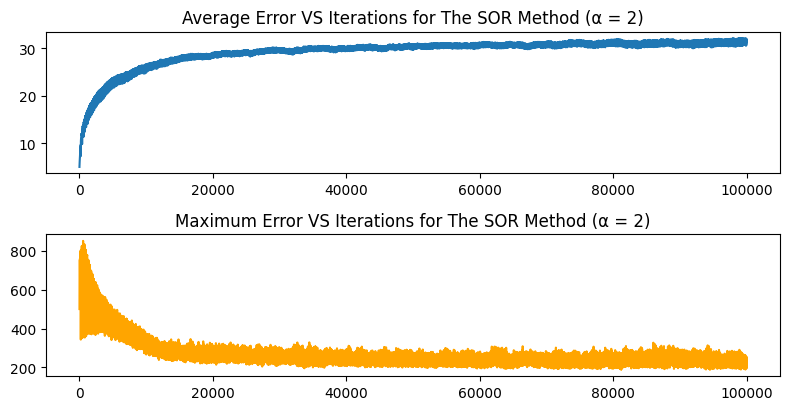

In [ ]:
plt.figure(figsize=(8, 6))

# First subplot
plt.subplot(3, 1, 1)  # 3 rows, 1 column, first subplot
plt.plot(iterations_SOR_w2, average_e_SOR_w2, label='Average Error')
plt.title(f'Average Error VS Iterations for The SOR Method (α = {w2})')

# Second subplot
plt.subplot(3, 1, 2)  # 3 rows, 1 column, second subplot
plt.plot(iterations_SOR_w2, max_e_SOR_w2, label='Maximum Error', color='orange')
plt.title(f'Maximum Error VS Iterations for The SOR Method (α = {w2})')

plt.tight_layout()

## b

In [ ]:
def solve_analytically(
    N,
    x,
    y,
    is_a_debugged_call = False,
    clear_before_printing = False
):
  V = 0
  i = 0
  while i < N:
    debug(is_a_debugged_call, i+1, clear_before_printing)
    if N < 226:
      sinh_term = np.sinh((i+1)*np.pi*(y))/np.sinh((i+1)*np.pi)
      # sinh_term = np.sinh((i+1)*np.pi*(1-y))/np.sinh((i+1)*np.pi)
    else:
      sinh_term = np.exp((i-1)*np.pi*(y-1))
      # sinh_term = np.exp(N*np.pi*(-x))

    V += 4000/((i+1) * np.pi) * np.sin((i+1)*np.pi*x) * sinh_term
    i += 2

  return V

In [ ]:
x_coords = np.linspace(0, 1, 100)
y_coords = np.linspace(-1, 0, 100)

x, y = np.meshgrid(x_coords, y_coords)

### N = 1

In [ ]:
N1 = 1
V_analytical_N1 = solve_analytically(N1, x, y, True)

plt.figure(figsize=(8, 6))
plt.contourf(x, y, V_analytical_N1, cmap='viridis')
plt.colorbar(label='Function Value')
plt.title(f'Analytical V for N = {N1}')
plt.xlabel('X axis')
plt.ylabel('Y axis')
plt.show()

### N = 10

In [ ]:
N10 = 10
V_analytical_N10 = solve_analytically(N10, x, y)

plt.figure(figsize=(8, 6))
plt.contourf(x, y, V_analytical_N10, cmap='viridis')
plt.colorbar(label='Function Value')
plt.title(f'Analytical V for N = {N10}')
plt.xlabel('X axis')
plt.ylabel('Y axis')
plt.show()

### N = 100

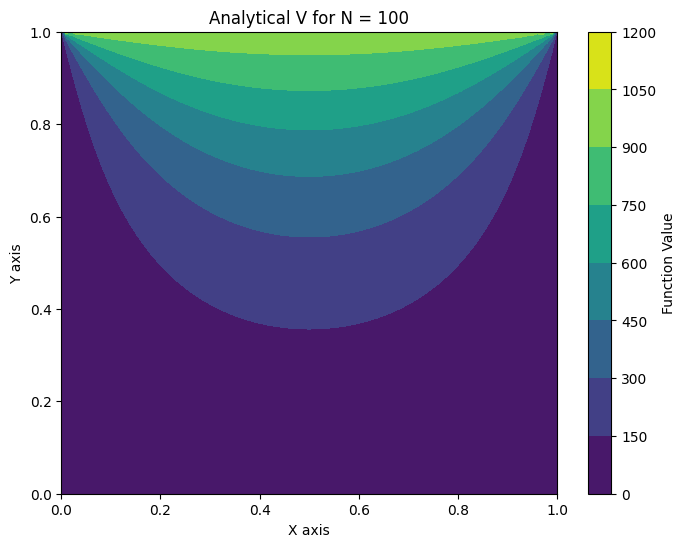

In [ ]:
N100 = 100
V_analytical_N100 = solve_analytically(N100, x, y)

plt.figure(figsize=(8, 6))
plt.contourf(x, y, V_analytical_N100, cmap='viridis')
plt.colorbar(label='Function Value')
plt.title(f'Analytical V for N = {N100}')
plt.xlabel('X axis')
plt.ylabel('Y axis')
plt.show()

### N = 1000

999


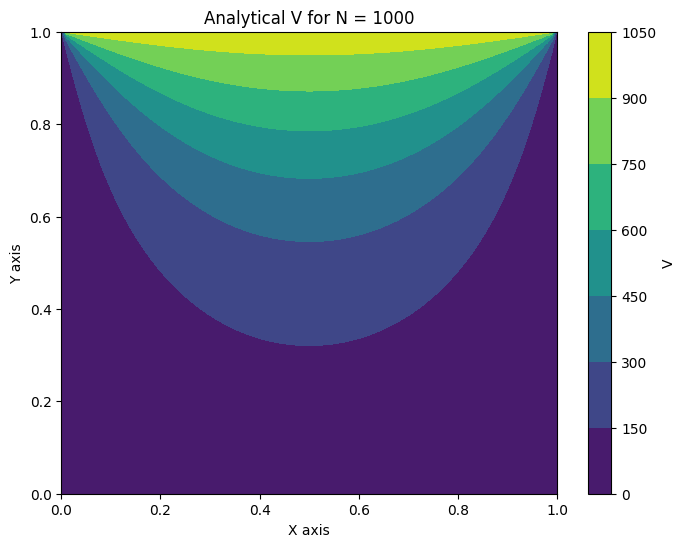

In [ ]:
N1000 = 1000
V_analytical_N1000 = solve_analytically(N1000, x, y, True, True)

plt.figure(figsize=(8, 6))
plt.contourf(x, y, V_analytical_N1000)
plt.colorbar(label='V')
plt.title(f'Analytical V for N = {N1000}')
plt.xlabel('X axis')
plt.ylabel('Y axis')
plt.show()

### Combined plots

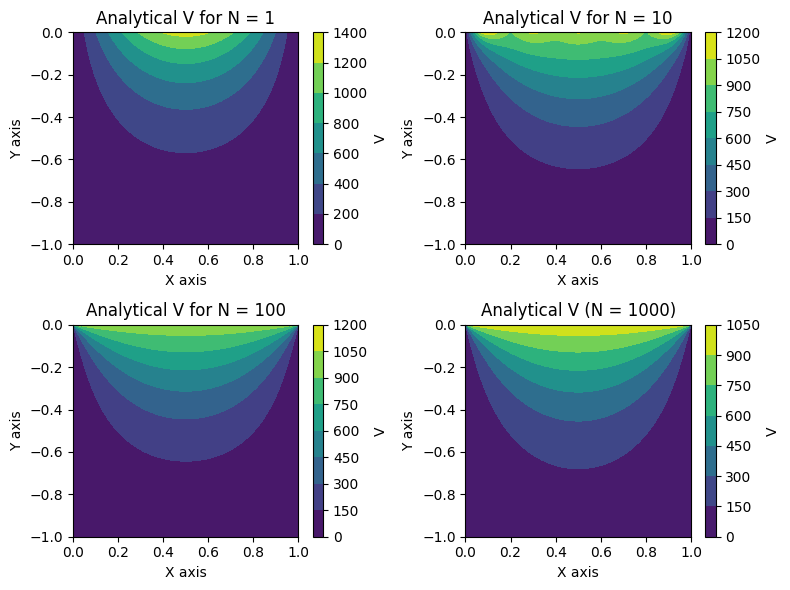

In [ ]:
plt.figure(figsize=(8, 6))

plt.subplot(2,2,1)
plt.contourf(x, y, V_analytical_N1)
plt.colorbar(label='V')
plt.title(f'Analytical V for N = {N1}')
plt.xlabel('X axis')
plt.ylabel('Y axis')

plt.subplot(2,2,2)
plt.contourf(x, y, V_analytical_N10)
plt.colorbar(label='V')
plt.title(f'Analytical V for N = {N10}')
plt.xlabel('X axis')
plt.ylabel('Y axis')

plt.subplot(2,2,3)
plt.contourf(x, y, V_analytical_N100)
plt.colorbar(label='V')
plt.title(f'Analytical V for N = {N100}')
plt.xlabel('X axis')
plt.ylabel('Y axis')

plt.subplot(2,2,4)
plt.contourf(x, y, V_analytical_N1000)
plt.colorbar(label='V')
plt.title(f'Analytical V (N = {N1000})')
plt.xlabel('X axis')
plt.ylabel('Y axis')


plt.tight_layout()

### Comparison

#### N=1000 VS Jacobi

<ipython-input-89-79b6d6c02aad>:25: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(new_ticks)
<ipython-input-89-79b6d6c02aad>:37: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(new_ticks)
<ipython-input-89-79b6d6c02aad>:49: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(new_ticks)


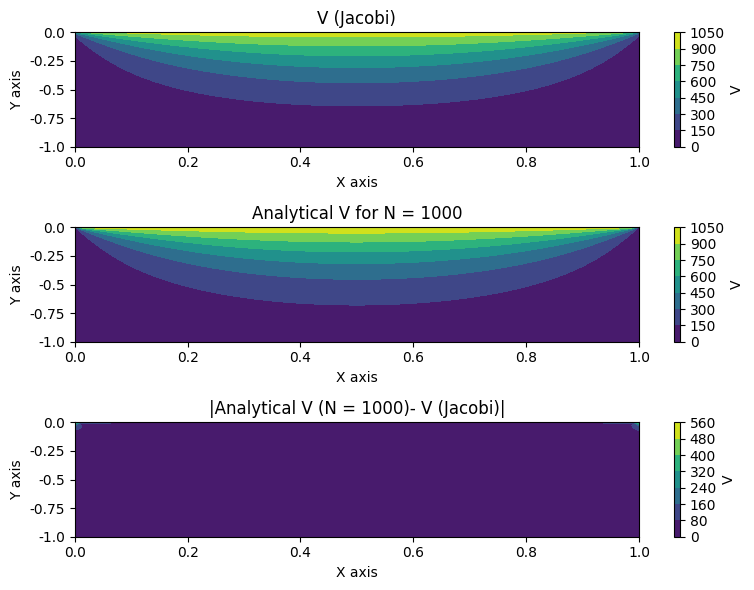

In [ ]:
unpacked_V_Jacobi = unpack_V(V_Jacobi)
unpacked_V_Jacobi = np.transpose(unpacked_V_Jacobi)

L_x, L_y = unpacked_V_Jacobi.shape

x_coords = np.linspace(0, 1, L_x)
y_coords = np.linspace(0, 1, L_y)

x, y = np.meshgrid(x_coords, y_coords)

V_analytical_N1000 = solve_analytically(N1000, x, y)

plt.figure(figsize=(8, 6))

plt.subplot(3,1,1)
plt.contourf(x, y, unpacked_V_Jacobi)
plt.colorbar(label='V')
plt.title(f'V (Jacobi)')
plt.xlabel('X axis')
plt.ylabel('Y axis')
# Get current y-axis tick locations and labels
ticks = plt.gca().get_yticks()
new_ticks = ticks - 1  # Subtracting 1 from all y-axis ticks
# Set the modified tick labels
plt.gca().set_yticklabels(new_ticks)

plt.subplot(3,1,2)
plt.contourf(x, y, V_analytical_N1000)
plt.colorbar(label='V')
plt.title(f'Analytical V for N = {N1000}')
plt.xlabel('X axis')
plt.ylabel('Y axis')
# Get current y-axis tick locations and labels
ticks = plt.gca().get_yticks()
new_ticks = ticks - 1  # Subtracting 1 from all y-axis ticks
# Set the modified tick labels
plt.gca().set_yticklabels(new_ticks)

plt.subplot(3,1,3)
plt.contourf(x, y, abs(V_analytical_N1000 - unpacked_V_Jacobi), cmap='viridis')
plt.colorbar(label='V')
plt.title(f'|Analytical V (N = {N1000})- V (Jacobi)|')
plt.xlabel('X axis')
plt.ylabel('Y axis')
# Get current y-axis tick locations and labels
ticks = plt.gca().get_yticks()
new_ticks = ticks - 1  # Subtracting 1 from all y-axis ticks
# Set the modified tick labels
plt.gca().set_yticklabels(new_ticks)


plt.tight_layout()

In [ ]:
np.max(abs(V_analytical_N1000 - unpacked_V_Jacobi))

499.8885642917557

#### N=10000 VS Jacobi

<ipython-input-90-cca33543980a>:25: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(new_ticks)
<ipython-input-90-cca33543980a>:37: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(new_ticks)
<ipython-input-90-cca33543980a>:49: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(new_ticks)


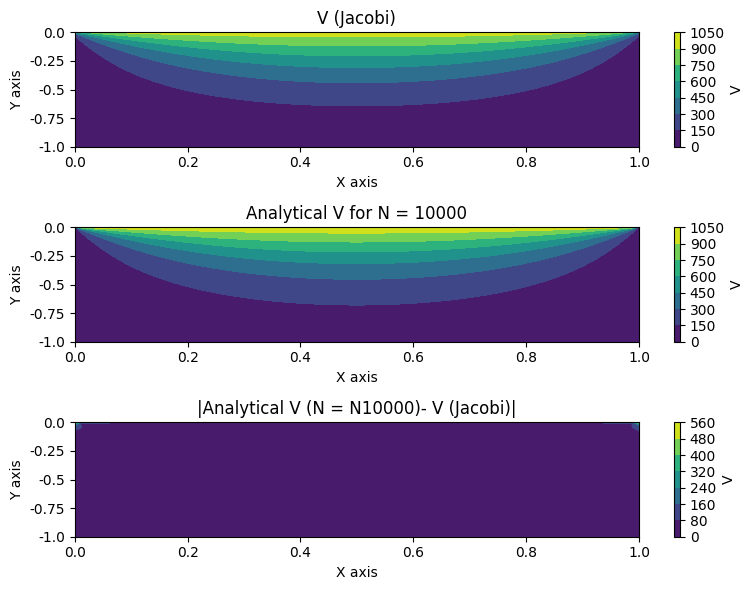

In [ ]:
unpacked_V_Jacobi = unpack_V(V_Jacobi)
unpacked_V_Jacobi = np.transpose(unpacked_V_Jacobi)

L_x, L_y = unpacked_V_Jacobi.shape

x_coords = np.linspace(0, 1, L_x)
y_coords = np.linspace(0, 1, L_y)

x, y = np.meshgrid(x_coords, y_coords)

V_analytical_N10000 = solve_analytically(10000, x, y)

plt.figure(figsize=(8, 6))

plt.subplot(3,1,1)
plt.contourf(x, y, unpacked_V_Jacobi)
plt.colorbar(label='V')
plt.title(f'V (Jacobi)')
plt.xlabel('X axis')
plt.ylabel('Y axis')
# Get current y-axis tick locations and labels
ticks = plt.gca().get_yticks()
new_ticks = ticks - 1  # Subtracting 1 from all y-axis ticks
# Set the modified tick labels
plt.gca().set_yticklabels(new_ticks)

plt.subplot(3,1,2)
plt.contourf(x, y, V_analytical_N10000)
plt.colorbar(label='V')
plt.title(f'Analytical V for N = 10000')
plt.xlabel('X axis')
plt.ylabel('Y axis')
# Get current y-axis tick locations and labels
ticks = plt.gca().get_yticks()
new_ticks = ticks - 1  # Subtracting 1 from all y-axis ticks
# Set the modified tick labels
plt.gca().set_yticklabels(new_ticks)

plt.subplot(3,1,3)
plt.contourf(x, y, abs(V_analytical_N10000 - unpacked_V_Jacobi), cmap='viridis')
plt.colorbar(label='V')
plt.title(f'|Analytical V (N = N10000)- V (Jacobi)|')
plt.xlabel('X axis')
plt.ylabel('Y axis')
# Get current y-axis tick locations and labels
ticks = plt.gca().get_yticks()
new_ticks = ticks - 1  # Subtracting 1 from all y-axis ticks
# Set the modified tick labels
plt.gca().set_yticklabels(new_ticks)


plt.tight_layout()

In [ ]:
np.max(abs(V_analytical_N1000 - unpacked_V_Jacobi))

499.8885642917557

#### N=1000 VS GS

<ipython-input-102-e6bf68a1a9ed>:25: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(new_ticks)
<ipython-input-102-e6bf68a1a9ed>:37: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(new_ticks)
<ipython-input-102-e6bf68a1a9ed>:49: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(new_ticks)


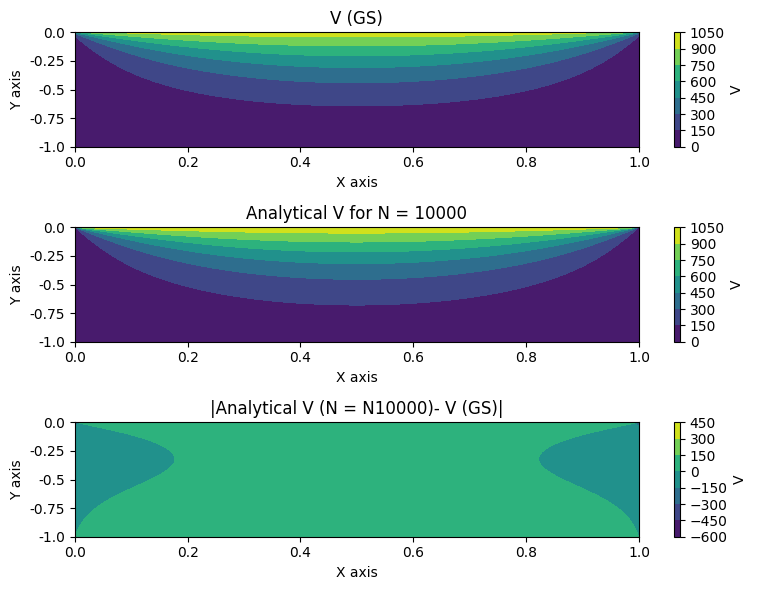

In [ ]:
unpacked_V_GS = unpack_V(V_GS)
unpacked_V_GS = np.transpose(unpacked_V_GS)

L_x, L_y = unpacked_V_GS.shape

x_coords = np.linspace(0, 1, L_x)
y_coords = np.linspace(0, 1, L_y)

x, y = np.meshgrid(x_coords, y_coords)

V_analytical_N10000 = solve_analytically(10000, x, y)

plt.figure(figsize=(8, 6))

plt.subplot(3,1,1)
plt.contourf(x, y, unpacked_V_GS)
plt.colorbar(label='V')
plt.title(f'V (GS)')
plt.xlabel('X axis')
plt.ylabel('Y axis')
# Get current y-axis tick locations and labels
ticks = plt.gca().get_yticks()
new_ticks = ticks - 1  # Subtracting 1 from all y-axis ticks
# Set the modified tick labels
plt.gca().set_yticklabels(new_ticks)

plt.subplot(3,1,2)
plt.contourf(x, y, V_analytical_N10000)
plt.colorbar(label='V')
plt.title(f'Analytical V for N = 10000')
plt.xlabel('X axis')
plt.ylabel('Y axis')
# Get current y-axis tick locations and labels
ticks = plt.gca().get_yticks()
new_ticks = ticks - 1  # Subtracting 1 from all y-axis ticks
# Set the modified tick labels
plt.gca().set_yticklabels(new_ticks)

plt.subplot(3,1,3)
plt.contourf(x, y, (V_analytical_N10000 - unpacked_V_GS), cmap='viridis')
plt.colorbar(label='V')
plt.title(f'|Analytical V (N = N10000)- V (GS)|')
plt.xlabel('X axis')
plt.ylabel('Y axis')
# Get current y-axis tick locations and labels
ticks = plt.gca().get_yticks()
new_ticks = ticks - 1  # Subtracting 1 from all y-axis ticks
# Set the modified tick labels
plt.gca().set_yticklabels(new_ticks)


plt.tight_layout()

# 2. Diffusion

## Commons

In [ ]:
x_step = 0.01
L = 1
x = np.arange(0, L+x_step, x_step)
N_x = len(x)

t_f = 10000

K = 200
C = 1000
ρ = 3000
l = K/(C*ρ)

T_0 = np.sin(x*np.pi)

a_0001 = 0.001/x_step**2*l
a_001 = 0.01/x_step**2*l
a_01 = 0.1/x_step**2*l
a_1 = 1/x_step**2*l
a_10 = 10/x_step**2*l
a_100 = 100/x_step**2*l
a_1000 = 1000/x_step**2*l

In [ ]:
def calc_T_exact(x, t):
  return np.sin(np.pi*x)*np.exp(-np.pi**2*l*t)

## a

In [ ]:
def solve_diffusion_equation_using_explicit_FTCS(T, a):
    N_x = len(T)
    T_new = np.zeros(N_x)
    for i in range(1,N_x-2):
      T_new[i] = (1-2*a)*T[i] + a*(T[i-1] + T[i+1])

    return T_new

In [ ]:
# Function to create individual plots
def create_plot(frame, x, T, t_step, T_exacts, times):
    plt.clf()
    plt.plot(
        x,
        T[frame],
        # linewidth=4,
        label='T_FTCS'
    )
    plt.plot(x, T_exacts[frame], label = 'T_exact')
    plt.plot(x, T_exacts[frame] - T[frame], label = 'T_exact - T')
    error = 0.01*np.sum(abs(T_exacts_01[frame] - T_01[frame]))
    plt.title(f'T VS x at t = {times[frame]} for ∆t = {t_step} with e({times[frame]}) = {error}')
    plt.ylim(0,1)
    plt.xlabel('x/L')
    plt.ylabel('Temperature (K)')
    plt.legend()

In [ ]:
N_t = int(10000/0.1)

T_01 = []
T_01.append(T_0)
T_01_new = T_0

T_exacts_01 = []
T_exacts_01.append(T_0)
T_exacts_new = T_0

times = [0]
t_rec = 500
# t_rec = 1

for t_i in range(1,N_t+1):
  T_01_new = solve_diffusion_equation_using_explicit_FTCS(T_01_new, a_01)
  T_exacts_01_new = calc_T_exact(x, (t_i)*0.1)
  if t_i%t_rec == 0:
    T_01.append(T_01_new)
    T_exacts_01.append(T_exacts_01_new)
    times.append((t_i)*0.1)
print((t_i)*0.1)

10000.0


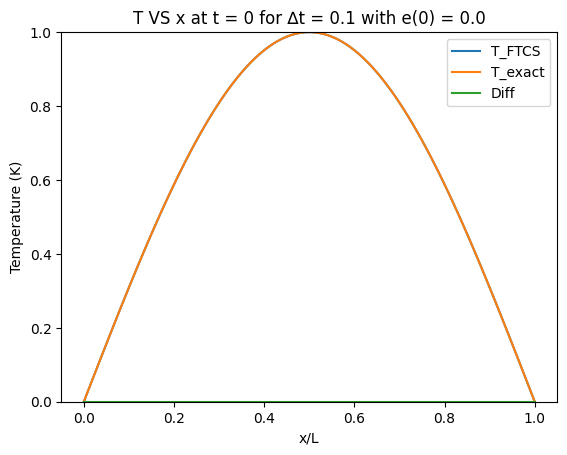

In [ ]:
# Create a GIF of plots
frames = int(N_t/t_rec)
animation = FuncAnimation(
    plt.figure(),
    create_plot,
    frames=len(T_01),
    interval=180,
    fargs = [x, T_01, 0.1, T_exacts_01, times]
)
animation.save('plots.gif', writer='pillow', fps=10)

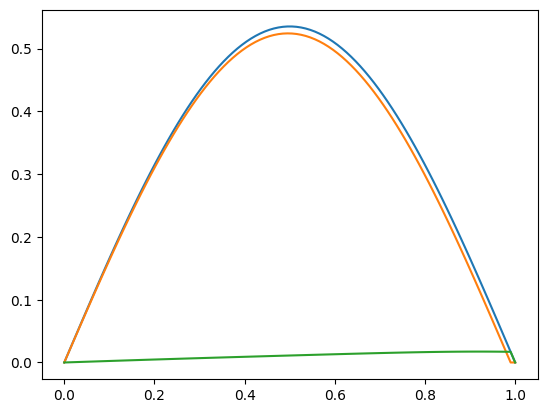

In [ ]:
plt.plot(x, T_exacts_01[-1], label='T_exact')
plt.plot(x, T_01[-1], label='T')
plt.plot(x, T_exacts_01[-1] - T_01[-1], label='Diff')

## b

In [ ]:
def calculate_FTCS_error(
    T_0,
    t_f,
    t_step,
    a,
    is_a_debugged_call = False,
    clear_before_printing = False
):
  T = T_0
  print(a)
  print(t_step)

  # for t_i in range(int(t_f/t_step)):
  for t_i in range(int(10000/0.1)):
    # T_new = np.zeros(100)
    # for i in range(1,100-2):
    #   T_new[i] = (1-2*a)*T[i] + a*(T[i-1] + T[i+1])
    debug(is_a_debugged_call, (t_i+1)*t_step, True)
    # debug(is_a_debugged_call, t_i)
    # T_new = (1-2*a)*T[1:-1] + a*(T[:-2] + T[2:])
    # T_new = np.insert(T_new, 0, 0)
    # T_new = np.append(T_new, [0])
    T = solve_diffusion_equation_using_explicit_FTCS(T, a)
    # T = (T_new)

  T_exact = calc_T_exact(x, (t_i+1)*t_step)
  diff = T_exact - T
  plt.plot(x, T_exact, label='T_exact')
  plt.plot(x, T, label='T')
  plt.plot(x, diff, label='Diff')
  plt.legend()
  # debug(is_a_debugged_call, T_exact, clear_before_printing)
  # debug(is_a_debugged_call, T, clear_before_printing)
  # debug(is_a_debugged_call, diff, clear_before_printing)
  e = (np.sum(abs(diff)))/100

  return e

### ∆t = 0.001

0.0006666666666666668
0.001


0.002919941052868241

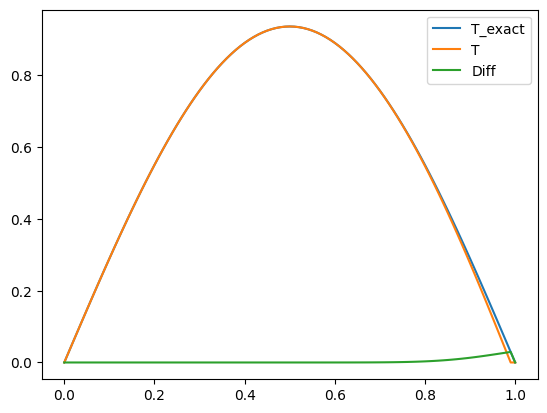

In [ ]:
e_FTCS_0001 = calculate_FTCS_error(T_0, t_f, 0.001, a_0001)
e_FTCS_0001

### ∆t = 0.01

0.006666666666666667
0.01


0.006042771684844218

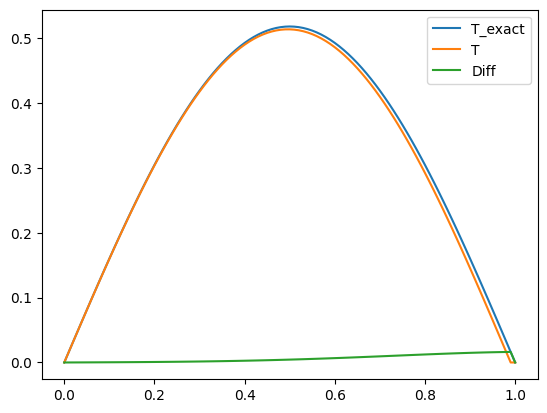

In [ ]:
e_FTCS_001 = calculate_FTCS_error(T_0, t_f, 0.01, a_001)
e_FTCS_001

### ∆t = 0.1

0.06666666666666667
0.1


0.00011426436741325487

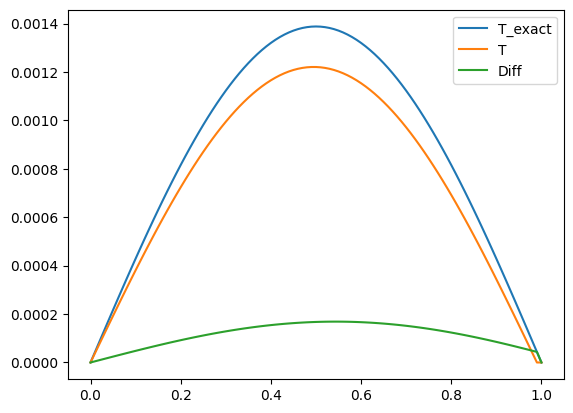

In [ ]:
e_FTCS_01 = calculate_FTCS_error(T_0, t_f, 0.1, a_01)
e_FTCS_01

### ∆t = 1

0.6666666666666667
1


<ipython-input-26-87aa39836a00>:5: RuntimeWarning: overflow encountered in double_scalars
  T_new[i] = (1-2*a)*T[i] + a*(T[i-1] + T[i+1])


inf

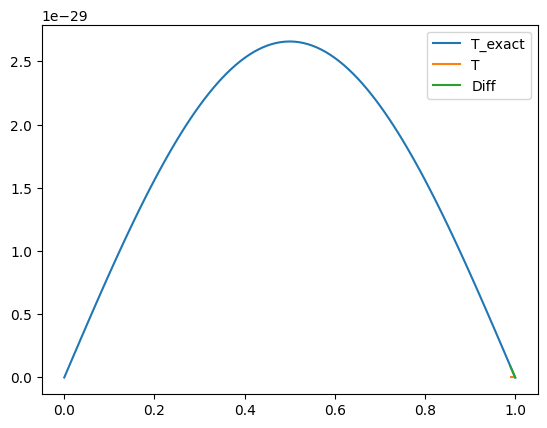

In [ ]:
e_FTCS_1 = calculate_FTCS_error(T_0, t_f, 1, a_1)
e_FTCS_1

### ∆t = 10

6.666666666666667
10


<ipython-input-26-87aa39836a00>:5: RuntimeWarning: overflow encountered in double_scalars
  T_new[i] = (1-2*a)*T[i] + a*(T[i-1] + T[i+1])
<ipython-input-26-87aa39836a00>:5: RuntimeWarning: invalid value encountered in double_scalars
  T_new[i] = (1-2*a)*T[i] + a*(T[i-1] + T[i+1])


nan

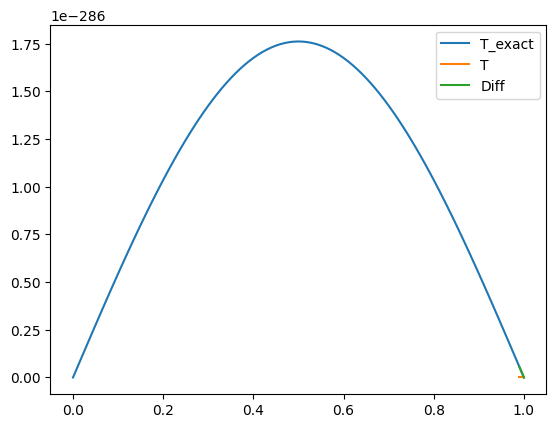

In [ ]:
e_FTCS_10 = calculate_FTCS_error(T_0, t_f, 10, a_10)
e_FTCS_10

### ∆t = 100

66.66666666666667
100


<ipython-input-26-87aa39836a00>:5: RuntimeWarning: overflow encountered in double_scalars
  T_new[i] = (1-2*a)*T[i] + a*(T[i-1] + T[i+1])
<ipython-input-26-87aa39836a00>:5: RuntimeWarning: invalid value encountered in double_scalars
  T_new[i] = (1-2*a)*T[i] + a*(T[i-1] + T[i+1])


nan

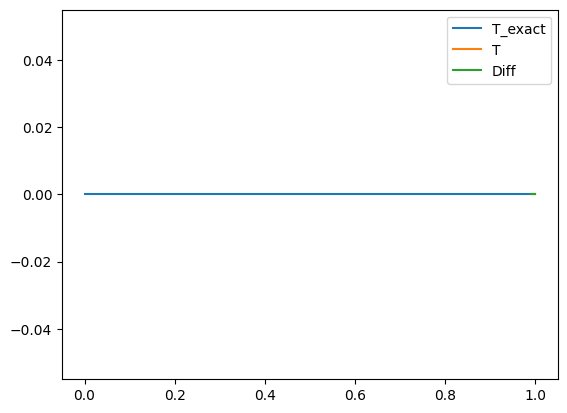

In [ ]:
e_FTCS_100 = calculate_FTCS_error(T_0, t_f, 100, a_100)
e_FTCS_100

### ∆t = 1000

666.6666666666667
1000


<ipython-input-26-87aa39836a00>:5: RuntimeWarning: overflow encountered in double_scalars
  T_new[i] = (1-2*a)*T[i] + a*(T[i-1] + T[i+1])
<ipython-input-26-87aa39836a00>:5: RuntimeWarning: invalid value encountered in double_scalars
  T_new[i] = (1-2*a)*T[i] + a*(T[i-1] + T[i+1])


nan

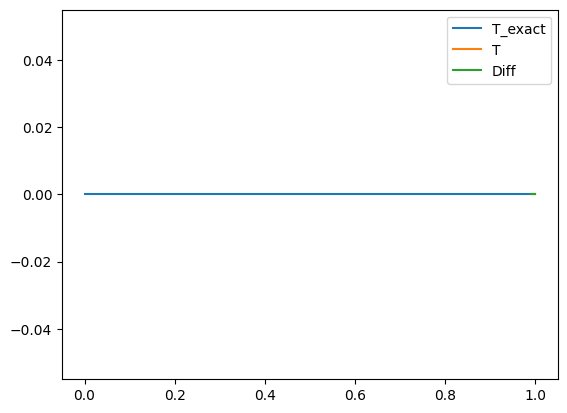

In [ ]:
e_FTCS_1000 = calculate_FTCS_error(T_0, t_f, 1000, a_1000)
e_FTCS_1000

### Combined Analysis

Text(0.5, 1.0, 'e(10000) VS ∆t for The FTCS Method')

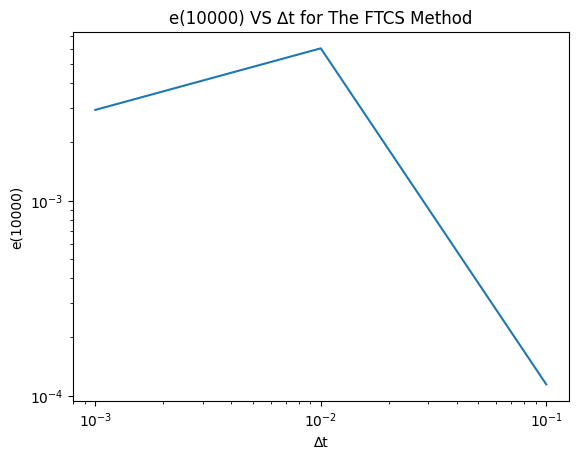

In [ ]:
errors = [
    e_FTCS_0001,
    e_FTCS_001,
    e_FTCS_01,
    # e_FTCS_1,
    # e_FTCS_10,
    # e_FTCS_100,
    e_FTCS_1000
]
t_steps = [
    0.001,
    0.01,
    0.1,
    # 1,
    # 10,
    # 100,
    1000
]

plt.loglog(t_steps, errors)
plt.xlabel('∆t')
plt.ylabel('e(10000)')
plt.title('e(10000) VS ∆t for The FTCS Method')

## c

### Commons

In [ ]:
def construct_dias(N_x, a):
  lower_dia = np.full(N_x-1, -a)
  lower_dia[-1] = 0

  upper_dia = np.full(N_x-1, -a)
  upper_dia[0] = 0

  main_dia = np.full(N_x, 1+2*a)
  main_dia[0] = 1
  main_dia[-1] = 1

  return lower_dia, main_dia, upper_dia

In [ ]:
## Tri Diagonal Matrix Algorithm(a.k.a Thomas algorithm) solver
@jit(f8[:] (f8[:],f8[:],f8[:],f8[:] ))
def TDMAsolver(a, b, c, d):
    '''
    TDMA solver, a b c d can be NumPy array type or Python list type.
    refer to http://en.wikipedia.org/wiki/Tridiagonal_matrix_algorithm
    and to http://www.cfd-online.com/Wiki/Tridiagonal_matrix_algorithm_-_TDMA_(Thomas_algorithm)
    '''
    nf = len(d) # number of equations
    ac, bc, cc, dc = map(np.array, (a, b, c, d)) # copy arrays
    for it in range(1, nf):
        mc = ac[it-1]/bc[it-1]
        bc[it] = bc[it] - mc*cc[it-1]
        dc[it] = dc[it] - mc*dc[it-1]

    xc = bc
    xc[-1] = dc[-1]/bc[-1]

    for il in range(nf-2, -1, -1):
        xc[il] = (dc[il]-cc[il]*xc[il+1])/bc[il]

    return xc

<ipython-input-51-9baca18afb0a>:2: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @jit(f8[:] (f8[:],f8[:],f8[:],f8[:] ))
<ipython-input-51-9baca18afb0a>:2: NumbaWarning: 
Compilation is falling back to object mode WITH looplifting enabled because Function "TDMAsolver" failed type inference due to: No implementation of function Function(<class 'map'>) found for signature:
 
 >>> map(Function(<built-in function array>), UniTuple(array(float64, 1d, A) x 4))
 
There are 2 candidate implementations:
      - Of which 2 did not match due to:
      Overload in function 'ol_map': File: numba/cpython/builtins.py: Line 725.
        With argument(s): '(Function(<built-in function array>

In [ ]:
def calculate_error(t_f, t_step, x_step, a, T_0, B):
  lower_dia, main_dia, upper_dia = construct_dias(N_x, a)

  T = T_0

  for t_i in range(1,1+int(t_f/t_step)):
    T_new = TDMAsolver(lower_dia, main_dia, upper_dia, np.dot(B, T))
    T = T_new

  T_exact = calc_T_exact(x, t_f)
  diff = T_exact - T
  e = (np.sum(abs(diff))*x_step)

  return e

### Backward-Euler

#### Commons

In [ ]:
B_BE = np.eye(len(x))

#### ∆t = 0.001

In [ ]:
e_BE_0001 = calculate_error(t_f, 0.001, x_step, a_0001, T_0, B_BE)
e_BE_0001

10000.0


4.802465393578539e-07

#### ∆t = 0.01

In [ ]:
e_BE_001 = calculate_error(t_f, 0.01, x_step, a_001, T_0, B_BE)
e_BE_001

10000.0


4.974703310512141e-07

#### ∆t = 0.1

In [ ]:
e_BE_01 = calculate_error(t_f, 0.1, x_step, a_01, T_0, B_BE)
e_BE_01

10000.0


6.697068230982248e-07

#### ∆t = 1

In [ ]:
e_BE_1 = calculate_error(t_f, 1, x_step, a_1, T_0, B_BE)
e_BE_1

10000


2.393168602634979e-06

#### ∆t = 10

In [ ]:
e_BE_10 = calculate_error(t_f, 10, x_step, a_10, T_0, B_BE)
e_BE_10

10000


1.973759964781514e-05

#### ∆t = 100

In [ ]:
e_BE_100 = calculate_error(t_f, 100, x_step, a_100, T_0, B_BE)
e_BE_100

10000


0.0002042369190434615

#### ∆t = 1000

In [ ]:
e_BE_1000 = calculate_error(t_f, 1000, x_step, l, T_0, B_BE)
e_BE_1000

10000


0.6356833001575626

#### Combined Analysis

Text(0.5, 1.0, 'Error VS ∆t for The Backward-Euler Method')

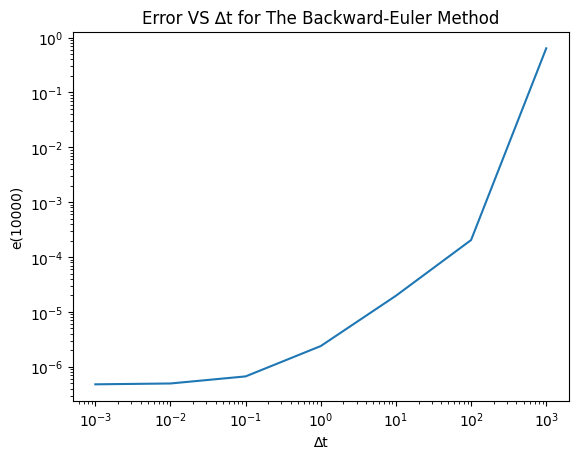

In [ ]:
errors_BE = [
    e_BE_0001,
    e_BE_001,
    e_BE_01,
    e_BE_1,
    e_BE_10,
    e_BE_100,
    e_BE_1000
]
t_steps = [
    0.001,
    0.01,
    0.1,
    1,
    10,
    100,
    1000
]

plt.loglog(t_steps, errors_BE)
plt.xlabel('∆t')
plt.ylabel('e(10000)')
plt.title('Error VS ∆t for The Backward-Euler Method')

### Crank-Nicolson

#### Commons

In [ ]:
def construct_B(a):
  B = (1-a)*np.eye(N_x)
  for i in range(1,N_x-1):
    for j in range(N_x):
      if abs(i-j) == 1:
        B[i][j] = a/2

  B[0][0] = 1
  # B[0][0] = 1-a/2
  # B[-1][-1] = 1-a/2
  B[-1][-1] = 1

  return B

In [ ]:
def construct_dias_CN(N_x, a):
  lower_dia = np.full(N_x-1, -a/2)
  lower_dia[-1] = 0

  upper_dia = np.full(N_x-1, -a/2)
  upper_dia[0] = 0

  main_dia = np.full(N_x, 1+a)
  main_dia[0] = 1
  # main_dia[0] = 1+a/2
  # main_dia[-1] = 1+a/2
  main_dia[-1] = 1

  return lower_dia, main_dia, upper_dia

In [ ]:
def calculate_error_CN(t_f, t_step, x_step, a, T_0, B):
  lower_dia, main_dia, upper_dia = construct_dias_CN(N_x, a)

  T = T_0

  for t_i in range(1,1+int(t_f/t_step)):
    T_new = TDMAsolver(lower_dia, main_dia, upper_dia, np.dot(B, T))
    T = T_new

  T_exact = calc_T_exact(x, t_f)
  diff = T_exact - T
  e = (np.sum(abs(diff))*x_step)

  return e

In [ ]:
def construct_B_G(a):
  B = (1-a)*np.eye(N_x)
  for i in range(1,N_x-1):
    for j in range(N_x):
      if abs(i-j) == 1:
        B[i][j] = a/2

  # B[0][0] = 1
  B[0][0] = 1-a/2
  B[-1][-1] = 1-a/2
  # B[-1][-1] = 1

  return B

In [ ]:
def construct_dias_CN_G(N_x, a):
  lower_dia = np.full(N_x-1, -a/2)
  lower_dia[-1] = 0

  upper_dia = np.full(N_x-1, -a/2)
  upper_dia[0] = 0

  main_dia = np.full(N_x, 1+a)
  # main_dia[0] = 1
  main_dia[0] = 1+a/2
  main_dia[-1] = 1+a/2
  # main_dia[-1] = 1

  return lower_dia, main_dia, upper_dia

In [ ]:
def calculate_error_CN_G(t_f, t_step, x_step, a, T_0, B):
  lower_dia, main_dia, upper_dia = construct_dias_CN_G(N_x, a)

  T = T_0

  for t_i in range(int(t_f/t_step)):
    T_new = TDMAsolver(lower_dia, main_dia, upper_dia, np.dot(B, T))
    T = T_new

  T_exact = calc_T_exact(x, )
  diff = T_exact - T
  e = (np.sum(abs(diff))*x_step)

  return e

#### ∆t = 0.001

In [ ]:
B_CN_0001 = construct_B(a_0001)
e_CN_0001 = calculate_error_CN(t_f, 0.001, x_step, a_0001, T_0, B_CN_0001)
e_CN_0001

4.783338305580166e-07

#### ∆t = 0.01

In [ ]:
B_CN_001 = construct_B(a_001)
e_CN_001 = calculate_error_CN(t_f, 0.01, x_step, a_001, T_0, B_CN_001)
e_CN_001

4.78334200015069e-07

In [ ]:
# B_CN_001_G = construct_B_G(a_001)
# e_CN_001_G = calculate_error_CN_G(t_f, 0.01, x_step, a_001, T_0, B_CN_001_G)
# e_CN_001_G

#### ∆t = 0.1

In [ ]:
B_CN_01 = construct_B(a_01)
e_CN_01 = calculate_error_CN(t_f, 0.1, x_step, a_01, T_0, B_CN_01)
e_CN_01

4.783321306825396e-07

In [ ]:
# B_CN_01_G = construct_B_G(a_01)
# e_CN_01_G = calculate_error_CN_G(t_f, 0.1, x_step, a_01, T_0, B_CN_01_G)
# e_CN_01_G

#### ∆t = 1

In [ ]:
B_CN_1 = construct_B(a_1)
e_CN_1 = calculate_error_CN(t_f, 1, x_step, a_1, T_0, B_CN_1)
e_CN_1

4.781243971013748e-07

In [ ]:
# B_CN_1_G = construct_B_G(a_1)
# e_CN_1_G = calculate_error_CN_G(t_f, 1, x_step, a_1, T_0, B_CN_1_G)
# e_CN_1_G

#### ∆t = 10

In [ ]:
B_CN_10 = construct_B(a_10)
e_CN_10 = calculate_error_CN(t_f, 10, x_step, a_10, T_0, B_CN_10)
e_CN_10

4.573510642993079e-07

In [ ]:
# B_CN_10_G = construct_B_G(a_10)
# e_CN_10_G = calculate_error_CN_G(t_f, 10, x_step, a_10, T_0, B_CN_10_G)
# e_CN_10_G

#### ∆t = 20

In [ ]:
a_20 = 20/x_step**2*l
B_CN_20 = construct_B(a_20)
e_CN_20 = calculate_error_CN(t_f, 20, x_step, a_20, T_0, B_CN_20)
e_CN_20

3.944029237854577e-07

#### ∆t = 50

In [ ]:
a_50 = 50/x_step**2*l
B_CN_50 = construct_B(a_50)
e_CN_50 = calculate_error_CN(t_f, 50, x_step, a_50, T_0, B_CN_50)
e_CN_50

4.61772310241281e-08

#### ∆t = 80

In [ ]:
a_80 = 80/x_step**2*l
B_CN_80 = construct_B(a_80)
e_CN_80 = calculate_error_CN(t_f, 80, x_step, a_80, T_0, B_CN_80)
e_CN_80

8.641336443909194e-07

#### ∆t = 100

In [ ]:
a_100 = 100/x_step**2*l
B_CN_100 = construct_B(a_100)
e_CN_100 = calculate_error_CN(t_f, 100, x_step, a_100, T_0, B_CN_100)
e_CN_100

1.6188658081967676e-06

In [ ]:
# B_CN_100_G = construct_B_G(a_100)
# e_CN_100_G = calculate_error_CN_G(t_f, 100, x_step, a_100, T_0, B_CN_100_G)
# e_CN_100_G

#### ∆t = 120

In [ ]:
a_120 = 120/x_step**2*l
B_CN_120 = construct_B(a_120)
e_CN_120 = calculate_error_CN(t_f, 120, x_step, a_120, T_0, B_CN_120)
e_CN_120

2.0968361113072736e-05

#### ∆t = 150

In [ ]:
a_150 = 150/x_step**2*l
B_CN_150 = construct_B(a_150)
e_CN_150 = calculate_error_CN(t_f, 150, x_step, a_150, T_0, B_CN_150)
e_CN_150

5.5619962722995965e-05

#### ∆t = 180

In [ ]:
a_180 = 180/x_step**2*l
B_CN_180 = construct_B(a_180)
e_CN_180 = calculate_error_CN(t_f, 180, x_step, a_180, T_0, B_CN_180)
e_CN_180

5.34298769751927e-05

#### ∆t = 200

In [ ]:
a_200 = 200/x_step**2*l
B_CN_200 = construct_B(a_200)
e_CN_200 = calculate_error_CN(t_f, 200, x_step, a_200, T_0, B_CN_200)
e_CN_200

7.896923600603555e-06

#### ∆t = 500

In [ ]:
a_500 = 500/x_step**2*l
B_CN_500 = construct_B(a_500)
e_CN_500 = calculate_error_CN(t_f, 500, x_step, a_500, T_0, B_CN_500)
e_CN_500

5.1271900477867196e-05

#### ∆t = 800

In [ ]:
a_800 = 800/x_step**2*l
B_CN_800 = construct_B(a_800)
e_CN_800 = calculate_error_CN(t_f, 800, x_step, a_800, T_0, B_CN_800)
e_CN_800

0.00010425730008753437

#### ∆t = 1000

In [ ]:
B_CN_1000 = construct_B(a_1000)
e_CN_1000 = calculate_error_CN(t_f, 1000, x_step, a_1000, T_0, B_CN_1000)
e_CN_1000

0.0001978700965704853

In [ ]:
# B_CN_1000_G = construct_B_G(a_1000)
# e_CN_1000_G = calculate_error_CN_G(t_f, 1000, x_step, a_1000, T_0, B_CN_1000_G)
# e_CN_1000_G

#### Combined Anaysis

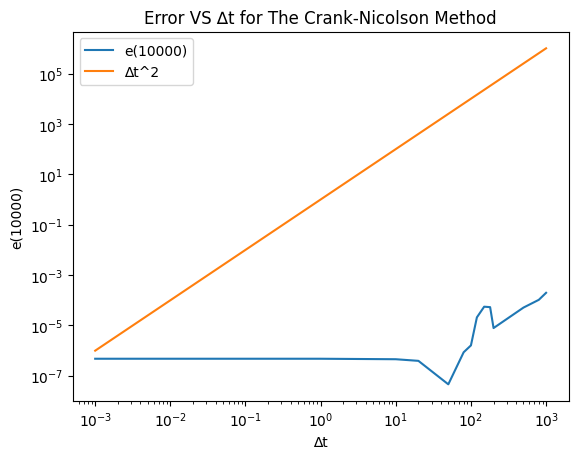

In [ ]:
errors_CN = [
    e_CN_0001,
    e_CN_001,
    e_CN_01,
    e_CN_1,
    e_CN_10,
    e_CN_20,
    e_CN_50,
    e_CN_80,
    e_CN_100,
    e_CN_120,
    e_CN_150,
    e_CN_180,
    e_CN_200,
    e_CN_500,
    e_CN_800,
    e_CN_1000
]
t_steps = [
    0.001,
    0.01,
    0.1,
    1,
    10,
    20,
    50,
    80,
    100,
    120,
    150,
    180,
    200,
    500,
    800,
    1000
]

plt.loglog(t_steps, errors_CN, label='e(10000)')
plt.xlabel('∆t')
plt.ylabel('e(10000)')
plt.title('Error VS ∆t for The Crank-Nicolson Method')

errors_CN = [
    0.001**2,
    0.01**2,
    0.1**2,
    1**2,
    10**2,
    100**2,
    120**2,
    150**2,
    180**2,
    200**2,
    500**2,
    800**2,
    1000**2
]
t_steps = [
    0.001,
    0.01,
    0.1,
    1,
    10,
    100,
    120,
    150,
    180,
    200,
    500,
    800,
    1000
]

plt.loglog(t_steps, errors_CN, label='∆t^2')

# errors_CN_G = [
#     # e_CN_0001,
#     e_CN_001_G,
#     e_CN_01_G,
#     e_CN_1_G,
#     e_CN_10_G,
#     e_CN_100_G,
#     e_CN_1000_G
# ]
# t_steps_G = [
#     # 0.001,
#     0.01,
#     0.1,
#     1,
#     10,
#     100,
#     1000
# ]

# plt.loglog(t_steps_G, errors_CN_G)

plt.legend()

### Dufort-Frankel

In [ ]:
def calculate_DF_error(
    t_step,
    a,
    is_a_debugged_call=False,
    clear_before_printing=False
):
  T_current = T_0
  T_prev = T_0

  for t_i in range(1,1+int(t_f/t_step)):
    T_next = np.zeros(len(x))
    for x_i in range(1,len(x)-1):
      T_next[x_i] = (2*a*(T_current[x_i-1] + T_current[x_i+1]) + (1-2*a)*T_prev[x_i])/(1+2*a)
    # T_next = (2*a*(T_current[:-2] + T_current[2:]) + (1-2*a)*T_prev[1:-1])/(1+2*a)
    # T_next = np.insert(T_next, 0, 0)
    # T_next = np.append(T_next, [0])
    T_prev = T_current
    T_current = T_next

  T_exact = calc_T_exact(x, t_f)
  diff = T_exact - T_current
  debug(is_a_debugged_call, diff)
  e = (np.sum(abs(diff))*x_step)

  return e

#### ∆t = 0.001

In [ ]:
e_DF_0001 = calculate_DF_error(0.001, a_0001)
e_DF_0001

4.78041035962366e-07

#### ∆t = 0.01

In [ ]:
e_DF_001 = calculate_DF_error(0.01, a_001)
e_DF_001

4.75209302803031e-07

#### ∆t = 0.1

In [ ]:
e_DF_01 = calculate_DF_error(0.1, a_01)
e_DF_01

4.2761585605055137e-07

#### ∆t = 1

In [ ]:
e_DF_1 = calculate_DF_error(1, a_1)
e_DF_1

1.9744413696507412e-06

#### ∆t = 5

In [ ]:
a_5 = 5*a_1
e_DF_5 = calculate_DF_error(1, a_5)
e_DF_5

0.0008836926611816817

#### ∆t = 10

In [ ]:
e_DF_10 = calculate_DF_error(10, a_10)
e_DF_10

0.0002094589434480393

#### ∆t = 50

In [ ]:
a_50 = 50*a_1
e_DF_50 = calculate_DF_error(1, a_50)
e_DF_50

0.0008836926611839793

#### ∆t = 100

In [ ]:
e_DF_100 = calculate_DF_error(100, a_100)
e_DF_100

0.29406991103453334

#### ∆t = 500

In [ ]:
a_500 = 500*a_1
e_DF_500 = calculate_DF_error(1, a_500)
e_DF_500

0.0008835124843525817

#### ∆t = 1000

In [ ]:
e_DF_1000 = calculate_DF_error(1000, a_1000)
e_DF_1000

0.6016164839460985

#### Combined Analysis

Text(0.5, 1.0, 'Error VS ∆t for The Dufort-Frankel Method')

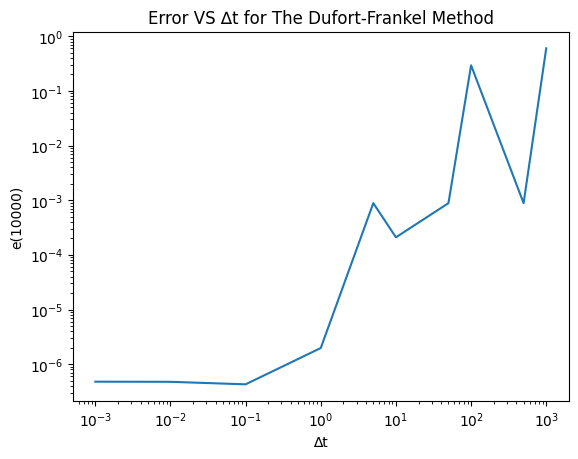

In [ ]:
errors_DF = [
    e_DF_0001,
    e_DF_001,
    e_DF_01,
    e_DF_1,
    e_DF_5,
    e_DF_10,
    e_DF_50,
    e_DF_100,
    e_DF_500,
    e_DF_1000
]
t_steps = [
    0.001,
    0.01,
    0.1,
    1,
    5,
    10,
    50,
    100,
    500,
    1000
]

from scipy.optimize import curve_fit
initial_guess = [1, 0, 0,0]  # Initial guess for parameters
def t_step_exponential(t_steps,a,b,c,d):
  return t_steps**a + c*t_steps**b + d
# optimized_params, _ = curve_fit(t_step_exponential, t_steps[3:], errors_DF[3:], initial_guess)
# print(optimized_params)

plt.loglog(t_steps, errors_DF)
# plt.loglog(t_steps[3:], t_step_exponential(t_steps[3:], *optimized_params))
plt.xlabel('∆t')
plt.ylabel('e(10000)')
plt.title('Error VS ∆t for The Dufort-Frankel Method')

## Combined Error Analyses

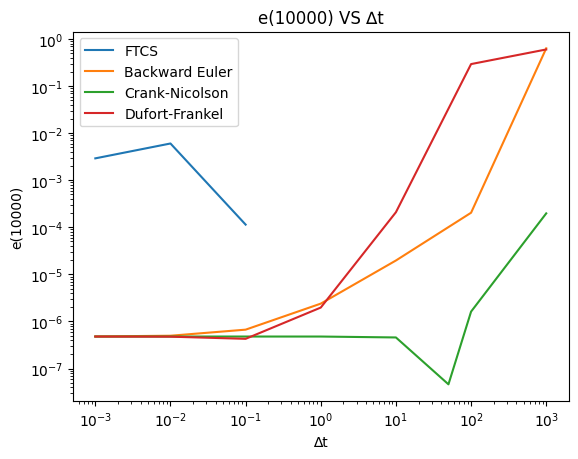

In [ ]:
errors_FTCS = [
    e_FTCS_0001,
    e_FTCS_001,
    e_FTCS_01,
    # e_FTCS_1,
    # e_FTCS_10,
    e_FTCS_100,
    e_FTCS_1000
    # 0.00010897558300973777,
    # 0.00010898648635320965,
    # 0.00010909551405441217
    # ,
    # #-----------------------,
    # #-----------------------,
    # # 1.6224312873746243e+222,
    # 393764121934699.1
]
t_steps_FTCS = [
    0.001,
    0.01,
    0.1,
    # 1,
    # 10,
    100,
    1000
]

plt.loglog(t_steps_FTCS, errors_FTCS, label='FTCS')
plt.xlabel('Time steps')
plt.ylabel('e(10000)')

errors_BE = [
    # e_BE_0001,
    # e_BE_001,
    # e_BE_01,
    # e_BE_1,
    # e_BE_10,
    # e_BE_100,
    # e_BE_1000
    4.802465393578539e-07,  #∆t = 10^-3
    4.974703310512141e-07,  #∆t = 10^-2
    6.697068230982248e-07,  #∆t = 10^-1
    2.393168602634979e-06,  #∆t = 1
    1.973759964781514e-05,  #∆t = 10
    0.0002042369190434615,  #∆t = 10^2
    0.6356833001575626      #∆t = 10^3
]
t_steps_BE = [
    0.001,
    0.01,
    0.1,
    1,
    10,
    100,
    1000
]

plt.loglog(t_steps_BE, errors_BE, label='Backward Euler')
plt.xlabel('∆t')
plt.ylabel('e(10000)')

errors_CN = [
    # e_CN_0001,
    # e_CN_001,
    # e_CN_01,
    # e_CN_1,
    # e_CN_10,
    # e_CN_100,
    # e_CN_1000
    4.783338305580166e-07,  #∆t = 10^-3
    4.78334200015069e-07,   #∆t = 10^-2
    4.783321306825396e-07,  #∆t = 10^-1
    4.781243971013748e-07,  #∆t = 1
    4.573510642993079e-07,  #∆t = 10,
    e_CN_50,
    1.6188658081967676e-06, #∆t = 10^2
    0.0001978700965704853   #∆t = 10^3
]
t_steps_CN = [
    0.001,
    0.01,
    0.1,
    1,
    10,
    50,
    100,
    1000
]

plt.loglog(t_steps_CN, errors_CN, label='Crank-Nicolson')
plt.xlabel('∆t')
plt.ylabel('e(10000)')

errors_DF = [
    e_DF_0001,
    e_DF_001,
    e_DF_01,
    e_DF_1,
    e_DF_10,
    e_DF_100,
    e_DF_1000
    # 0.00010897463099406084,
    # 0.00010897713820934414,
    # 0.00010901965429851075,
    # 0.00011118778391415304,
    # 0.0002981490649035111,
    # 0.29412757178324866,
    # 0.5949208079911885
]
t_steps_DF = [
    0.001,
    0.01,
    0.1,
    1,
    10,
    100,
    1000
]

plt.loglog(t_steps_DF, errors_DF, label='Dufort-Frankel')
plt.xlabel('∆t')
plt.ylabel('e(10000)')

plt.title('e(10000) VS ∆t')
plt.legend()

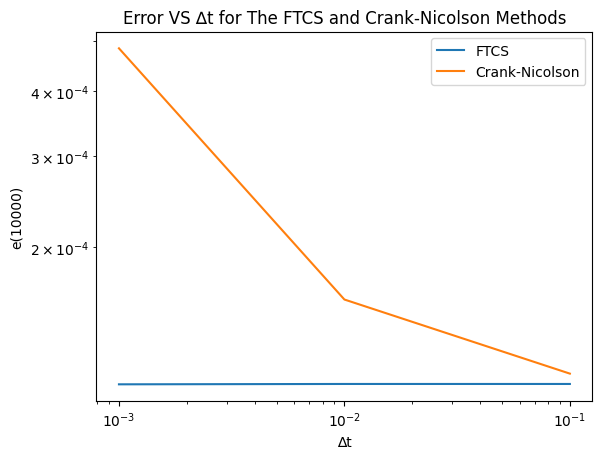

In [ ]:
t_steps = [
    0.001,
    0.01,
    0.1,
    # 1,
    # 10,
    # 100,
    # 1000
]

errors_FTCS = [
    0.00010897609712635142,
    0.00010914691766508657,
    0.00010914691766508657,
    # e_FTCS_1,
    # e_FTCS_10,
    # 1.6224312873746243e+222,
    # 393764121934699.1
]

plt.loglog(t_steps, errors_FTCS, label='FTCS')
plt.xlabel('Time steps')
plt.ylabel('e(10000)')

errors_CN = [
    0.000483447907795283,
    0.00015871464454909719,
    0.00011426972016919441,
    # e_CN_1,
    # e_CN_10,
    # 1.262716291383052e+222,
    # 347378175560221.1
]


plt.loglog(t_steps, errors_CN, label='Crank-Nicolson')
plt.xlabel('∆t')
plt.ylabel('e(10000)')


plt.title('Error VS ∆t for The FTCS and Crank-Nicolson Methods')
plt.legend()

# 3. Solitons (Yaay!!)

## Commons

In [ ]:
N_x_solitons = 130
x_step_solitons = 0.4
x_solitons = np.linspace(0,N_x_solitons*x_step_solitons,N_x_solitons)
# print(x_solitons)

time_step_solitons = 0.1
N_t_solitons = 2000

ϵ = 0.2
µ = 0.1

In [ ]:
def calculate_u_1_per_x(u_curr_h, u_curr_i, u_curr_j, u_curr_k, u_curr_l):
  u_next_x_i = u_curr_j \
  - ϵ/6*time_step_solitons/x_step_solitons * (u_curr_i + u_curr_j + u_curr_k) \
  * (u_curr_k - u_curr_i) \
  - µ/2*time_step_solitons/x_step_solitons**3 * (u_curr_l + 2*u_curr_i -2*u_curr_k - u_curr_h)

  return u_next_x_i

In [ ]:
def calculate_u_1(u_0, u_x0, u_L):
  u_1 = []
  # u_1[0]
  u_1.append(u_x0)
  # u_1[1]
  u_1.append(
      calculate_u_1_per_x(
        u_0[0],
        u_0[0],
        u_0[1],
        u_0[2],
        u_0[3]
      )
  )

  # u_1[2] -- u_1[N_x_solitons-2]
  for x_i in range(2,N_x_solitons-2):
    u_0_h = u_0[x_i-2]
    u_0_i = u_0[x_i-1]
    u_0_j = u_0[x_i]
    u_0_k = u_0[x_i+1]
    u_0_l = u_0[x_i+2]

    u_1.append(calculate_u_1_per_x(u_0_h, u_0_i, u_0_j, u_0_k, u_0_l))

  # u_1[-2]
  u_1.append(
      calculate_u_1_per_x(
        u_0[-4],
        u_0[-3],
        u_0[-2],
        u_0[-1],
        u_0[-1]
      )
  )
  # u_1[-1]
  u_1.append(u_L)

  return u_1

In [ ]:
def calculate_u_per_x(u_prev_j, u_curr_h, u_curr_i, u_curr_j, u_curr_k, u_curr_l):
  u_next_x_i = u_prev_j \
  - ϵ/3*time_step_solitons/x_step_solitons * (u_curr_i + u_curr_j + u_curr_k) \
  * (u_curr_k - u_curr_i) \
  - µ*time_step_solitons/x_step_solitons**3 * (u_curr_l + 2*u_curr_i -2*u_curr_k - u_curr_h)

  return u_next_x_i

In [ ]:
def calculate_u(u_prev, u_curr, u_x0, u_L):
  u = []
  # u[0]
  u.append(u_x0)
  # u[1]
  u.append(
      calculate_u_per_x(
        u_prev[1],
        u_curr[0],
        u_curr[0],
        u_curr[1],
        u_curr[2],
        u_curr[3]
      )
  )

  # u[2] -- u[N_x_solitons-2]
  for x_i in range(2,N_x_solitons-2):
    u_curr_h = u_curr[x_i-2]
    u_curr_i = u_curr[x_i-1]
    u_curr_j = u_curr[x_i]
    u_curr_k = u_curr[x_i+1]
    u_curr_l = u_curr[x_i+2]

    u.append(calculate_u_per_x(u_prev[x_i], u_curr_h, u_curr_i, u_curr_j, u_curr_k, u_curr_l))

  # u[-2]
  u.append(
      calculate_u_per_x(
        u_prev[-2],
        u_curr[-4],
        u_curr[-3],
        u_curr[-2],
        u_curr[-1],
        u_curr[-1]
      )
  )
  # u[-1]
  u.append(u_L)

  return u

In [ ]:
def create_solitons_plot(frame, x, U, time, title, y_min, y_max):
    plt.clf()

    plt.plot(x, U[frame])
    plt.title(f'{title} at t = {time[frame]}')
    plt.ylim(-3,3)
    plt.xlabel('x')
    plt.ylabel('Disturbance U(x)')

## b

In [ ]:
u_0 = 0.5*(1-np.tanh((x_solitons-25)/5))
U = [u_0]
time_solitons= [0]

t_rec = 0
u_curr = calculate_u_1(u_0,1,0)
u_prev = u_0

for t_i in range(N_t_solitons):
# for t_i in range(1):
  t_rec += 1
  u = calculate_u(u_prev, u_curr,1,0)
  u_prev = u_curr
  u_curr = u

  if t_rec == 250:
  # if t_rec:
    U.append(u)
    time_solitons.append(t_i)
    t_rec = 0

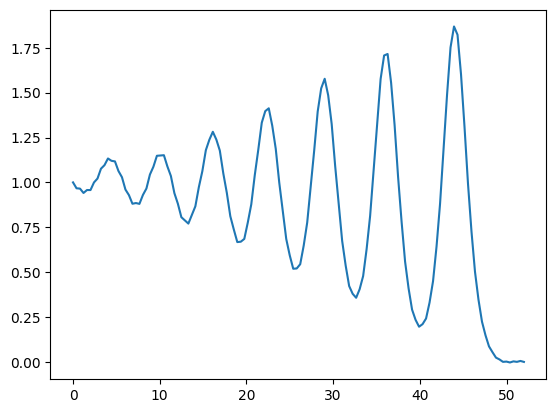

In [ ]:
plt.plot(x_solitons, U[-1])
# plt.ylim(0,1.1)

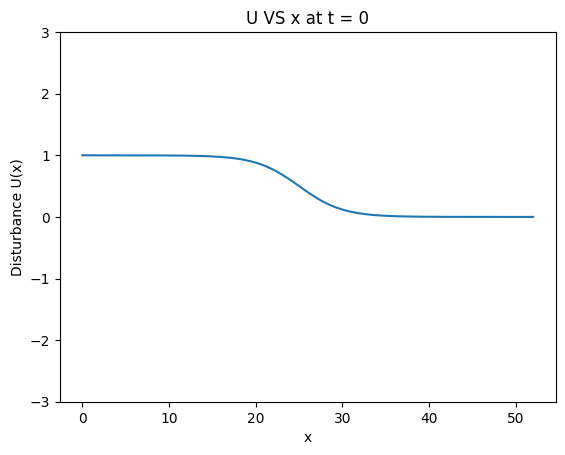

In [ ]:
frames = len(U)
animation = FuncAnimation(
    plt.figure(),
    create_solitons_plot,
    frames=frames,
    interval=100,
    fargs = [x_solitons, U, time_solitons, 'U VS x',0,2]
)
animation.save('plots.gif', writer='pillow', fps=5)

## c (for COLLISION!!)

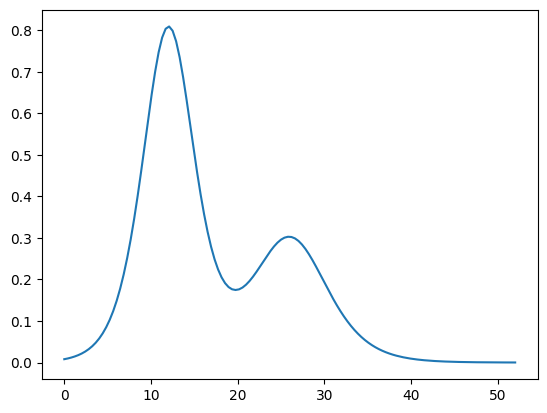

In [ ]:
u_0_collision = 0.8*(1-np.tanh(3*x_solitons/12 -3)**2) \
  + 0.3*(1-np.tanh(4.5*x_solitons/26 -4.5)**2)
U_collision = [u_0_collision]
plt.plot(x_solitons, u_0_collision)
time_solitons_collision= [0]

t_rec_collision = 0
u_curr = calculate_u_1(u_0_collision, 0, 0)
u_prev = u_0_collision

for t_i in range(3*N_t_solitons):
# for t_i in range(1):
  t_rec_collision += 1
  u = calculate_u(u_prev, u_curr, 0, 0)
  u_prev = u_curr
  u_curr = u

  if t_rec_collision == 250:
  # if t_rec_collision:
    U_collision.append(u)
    time_solitons_collision.append(t_i)
    t_rec_collision = 0

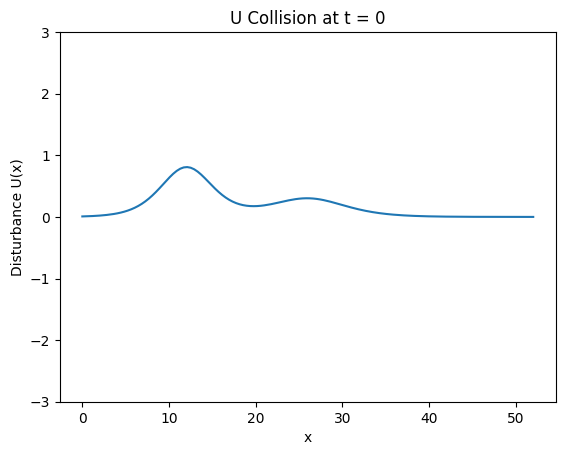

In [ ]:
frames = len(U_collision)
animation = FuncAnimation(
    plt.figure(),
    create_solitons_plot,
    frames=frames,
    interval=100,
    fargs = [x_solitons, U_collision, time_solitons_collision, 'U Collision', 0, 1]
)
animation.save('plots.gif', writer='pillow', fps=10)

# Workshop

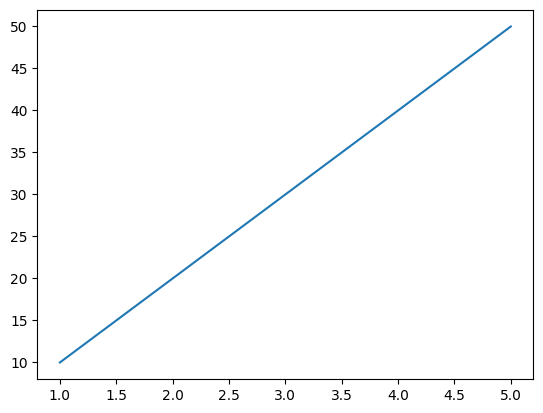

In [ ]:
import matplotlib.pyplot as plt

# Generating sample data
x = [1, 2, 3, 4, 5]
y = [10, 20, 30, 40, 50]

plt.plot(x, y)
plt.gca().invert_yaxis()  # Inverting only the y-axis ticks
plt.gca().set_ylim(plt.gca().get_ylim()[::-1])  # Reversing y-axis limits
plt.show()


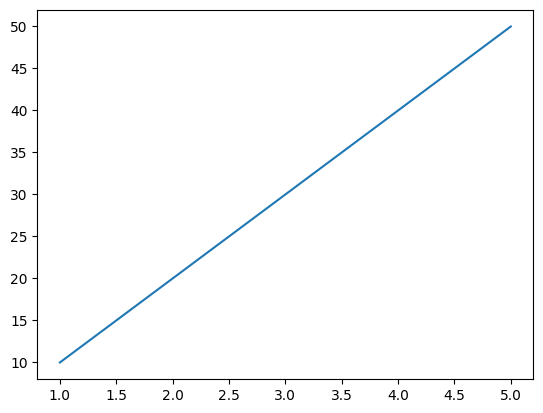

In [ ]:
import matplotlib.pyplot as plt

# Generating sample data
x = [1, 2, 3, 4, 5]
y = [10, 20, 30, 40, 50]

plt.plot(x, y)
# plt.gca().invert_yaxis()  # Flipping y-axis ticks
plt.show()

In [ ]:
from scipy import linalg

def sor_solver(A, b, omega, initial_guess, convergence_criteria):
    """
    This is an implementation of the pseudo-code provided in the Wikipedia article.
    Arguments:
        A: nxn numpy matrix.
        b: n dimensional numpy vector.
        omega: relaxation factor.
        initial_guess: An initial solution guess for the solver to start with.
        convergence_criteria: The maximum discrepancy acceptable to regard the current solution as fitting.
    Returns:
        phi: solution vector of dimension n.
    """
    step = 0
    phi = initial_guess[:]
    residual = linalg.norm(A @ phi - b)  # Initial residual
    while residual > convergence_criteria:
        for i in range(A.shape[0]):
            sigma = 0
            for j in range(A.shape[1]):
                if j != i:
                    sigma += A[i, j] * phi[j]
            phi[i] = (1 - omega) * phi[i] + (omega / A[i, i]) * (b[i] - sigma)
        residual = linalg.norm(A @ phi - b)
        step += 1
        print("Step {} Residual: {:10.6g}".format(step, residual))
    return phi

In [ ]:
n = 99
A, b = construct(n)
sor_solver(A, b, 1.75, np.zeros(n*n), 1e-3)

Step 1 Residual:    9512.68
Step 2 Residual:    7236.51
Step 3 Residual:    5530.33
Step 4 Residual:    4251.28
Step 5 Residual:    3291.24
Step 6 Residual:    2569.09
Step 7 Residual:    2024.27
Step 8 Residual:    1611.66
Step 9 Residual:    1297.61
Step 10 Residual:    1057.03
Step 11 Residual:    871.229
Step 12 Residual:    726.361
Step 13 Residual:    612.214
Step 14 Residual:    521.279
Step 15 Residual:    448.042
Step 16 Residual:    388.453
Step 17 Residual:    339.523
Step 18 Residual:    299.029
Step 19 Residual:    265.296
Step 20 Residual:    237.046
Step 21 Residual:    213.287
Step 22 Residual:    193.233
Step 23 Residual:    176.255
Step 24 Residual:    161.837
Step 25 Residual:    149.557
Step 26 Residual:     139.06
Step 27 Residual:    130.053
Step 28 Residual:    122.287
Step 29 Residual:    115.557
Step 30 Residual:    109.689
Step 31 Residual:    104.539
Step 32 Residual:    99.9877
Step 33 Residual:    95.9372
Step 34 Residual:    92.3058
Step 35 Residual:    89

In [ ]:
def append_to_list(test_list, new_ele):
  test_list.append(new_ele)

test_list = [0]
append_to_list(test_list, 1)
test_list

[0, 1]

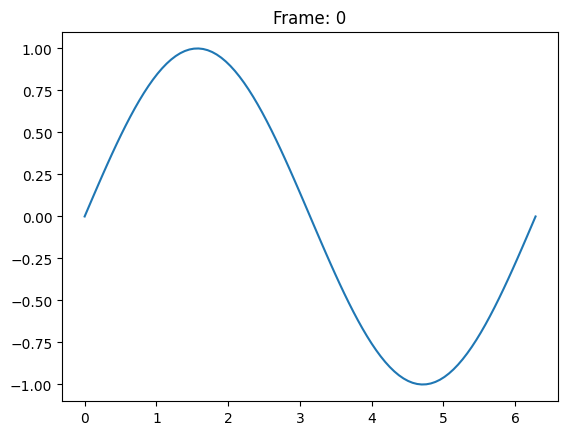

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation
from PIL import Image

# Function to create individual plots
def create_plot(frame):
    plt.clf()
    x = np.linspace(0, 2 * np.pi, 100)
    y = np.sin(x + frame / 10.0)
    plt.plot(x, y)
    plt.title(f'Frame: {frame}')

# Create a GIF of plots
frames = 50
animation = FuncAnimation(plt.figure(), create_plot, frames=frames, interval=100)
animation.save('plots.gif', writer='pillow', fps=10)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data
x = np.arange(10)
y = np.random.randint(1, 20, size=10)

plt.plot(x, y)
plt.xlabel('Original X-axis')

# Define custom tick positions and labels
custom_ticks = [0, 2, 4, 6, 8]  # Example custom tick positions
custom_labels = ['A', 'B', 'C', 'D', 'E']  # Example custom labels for the ticks

# Set the custom ticks and labels on the x-axis at the bottom
plt.xticks(custom_ticks, custom_labels, bottom=True)

plt.title('Change Position of X-axis Ticks to the Bottom')
plt.show()


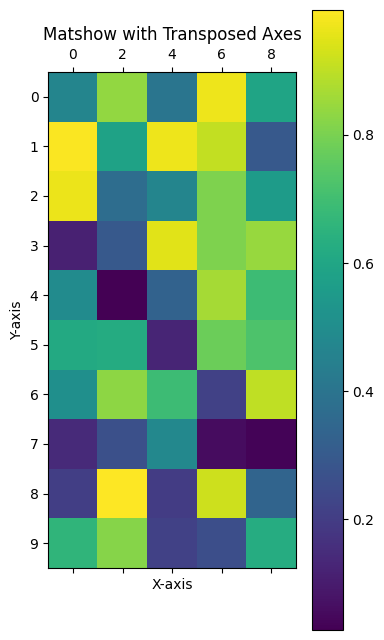

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create a sample matrix
matrix = np.random.rand(5, 10)

# Transpose the matrix to change the axes
transposed_matrix = np.transpose(matrix)

# Plot using matshow
plt.matshow(transposed_matrix)

# Modifying the tick labels
plt.xticks([0,1,2,3,4], [0,2,4,6,8])
plt.yticks(np.arange(transposed_matrix.shape[0]), np.arange(transposed_matrix.shape[0]))

plt.xlabel('X-axis')  # Adjust the labels according to the new orientation
plt.ylabel('Y-axis')
plt.title('Matshow with Transposed Axes')
plt.colorbar()  # Adding a color bar for reference
plt.show()


In [ ]:
import numpy as np

# Example initial array
initial_array = np.array([3, 7, 2, 8, 4])

# Pad the initial array to handle edge cases
padded_array = np.pad(initial_array, (1, 1), mode='constant')

# Generate the new array based on the formula
# new_array = padded_array[:-2] - padded_array[1:-1] + padded_array[2:]
new_array = initial_array[:-2] - initial_array[1:-1] + initial_array[2:]

print("Initial Array:", initial_array)
print("New Array:", new_array)


Initial Array: [3 7 2 8 4]
New Array: [-2 13 -2]


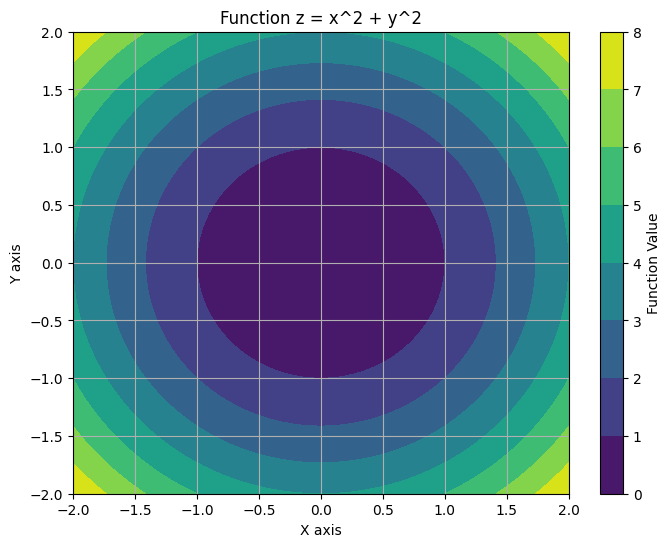

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the range of coordinates
x_coords = np.linspace(-2, 2, 100)
y_coords = np.linspace(-2, 2, 100)

# Create coordinate matrices using meshgrid
x, y = np.meshgrid(x_coords, y_coords)

# Define the function to apply to each grid point
def my_function(x, y):
    return x**2 + y**2

# Apply the function to each grid point
z = my_function(x, y)

# Plot the result
plt.figure(figsize=(8, 6))
plt.contourf(x, y, z)  # Contour plot
plt.colorbar(label='Function Value')
plt.title('Function z = x^2 + y^2')
plt.xlabel('X axis')
plt.ylabel('Y axis')
plt.grid(True)
plt.show()
